# 3.6: Model performance comparison
This notebook will assess the performance of the models generated in step 3.3, 3.4 and 3.5. 

## 3.6.1 system setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import os
import sys
import numpy as np
import json
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

import plotly.graph_objects as go


sys.path.append('../../utils')
from  configloader import Configloader
import cnn_helpers
import vit_helpers
import implot
import file_io
import style

#from sklearn.preprocessing import LabelEncoder
#import tensorflow as tf

from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

2025-05-02 11:42:10.977297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-05-02 11:42:13.005305: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-02 11:42:15.339290: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-02 11:42:15.339362: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [4]:
config = Configloader()

basedir = config.get('settings', 'image_directory')
csv_data_dir = config.get('dir_augmentations', 'csv_dir')

#augment_base = os.path.join(basedir, 'augmentated data', 'brand phase')


In [5]:
CNN_SHAPE = 224

PHASE = 'brand phase'

MODELDIR = os.path.join(
    config.get('directories', 'root_dir'), 
    config.get('directories', 'final_models_dirname'), 
    config.get('directories', 'brandphase'),
    )

CROP = True  #crop on bbox

In [6]:
csv_dir = os.path.join(basedir, csv_data_dir, PHASE)  #where the train/test/valid split in step 3.1 was done.

In [7]:
def decode_labels(decoder, encoded_labels): 
    return [decoder[i] for i in encoded_labels]

def ez_compare(actuals, preds, brand_names):
    cm = implot.make_cm(actuals, preds, brand_names, embed=True)
    metrics = implot.quick_metrics(actuals, preds)
    #TODO use the implot.quicplot method for quickmetrics outcome!

    return cm, metrics


## 3.6.2 Data loading
This notebook will use NON-augemented data from the validation set! 

In [8]:
validation_df_path = os.path.join(csv_dir, config.get('csv_names', 'brand_validation'))
validation_df = pd.read_csv(validation_df_path)

In [9]:
validation_df = cnn_helpers.shuffle_df(validation_df)
validation_df

,image_id,model_label,model_score,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,brand,abs_path
0,12413793,frontright,1.000000,-1,-1,-1,-1,12413793,0.885908,0.999987,0.971923,0.932645,volkswagen,/home/frederic/Documents/automotive_image_data...
1,2797866,frontright,1.000000,32,148,718,482,2797866,0.988465,0.999452,0.976957,0.981627,hyundai,/home/frederic/Documents/automotive_image_data...
2,4931703,rearright,0.999997,13,146,726,549,4931703,0.986515,0.999996,0.986339,0.884543,ford,/home/frederic/Documents/automotive_image_data...
3,1719338,rearright,1.000000,74,111,677,480,1719338,0.999928,1.000000,0.998289,0.999364,fiat,/home/frederic/Documents/automotive_image_data...
4,10565014,frontright,0.999068,72,74,720,472,10565014,0.935505,0.999995,0.988833,0.983159,bmw,/home/frederic/Documents/automotive_image_data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399056,8624689,rearleft,0.999999,182,133,570,431,8624689,0.975599,0.999895,0.965364,0.651923,suzuki,/home/frederic/Documents/automotive_image_data...
399057,11553370,rearright,1.000000,51,119,697,540,11553370,0.997586,1.000000,0.999243,0.999448,hyundai,/home/frederic/Documents/automotive_image_data...
399058,7479164,frontright,1.000000,71,144,683,519,7479164,0.998555,0.999999,0.998091,0.997148,opel,/home/frederic/Documents/automotive_image_data...
399059,8278366,frontleft,1.000000,44,114,713,492,8278366,0.996441,0.999996,0.996899,0.993753,toyota,/home/frederic/Documents/automotive_image_data...


In [10]:
#RUN SMALL TEST #TODO remove this
#validation_df = validation_df.sample(20000)

In [11]:
g = implot.quickplot(validation_df, 'model_label')
g.update_layout(
    title='Distribution of angles in validation set', 
    width=1000, 
    height=600
    )

In [12]:
g = implot.quickplot(validation_df, 'brand')
g.update_layout(
    title='Distribution of brands in validation set', 
    width=1600, 
    height=900
    )

this is good - we still remember the graphs made in EDA phases and post-applier notebooks that showed similar distributions. Now assess the models. 

## 3.6.3 Single logic block for inferring all trained models
One block of code to infer all trained models, will store them in a multidimensional dictionary with the type of model, angle and then scores/actuals and decoders.

In [13]:
#Read VIT config: 
vit_variants = vit_helpers.get_vit_configurations(
    os.path.join(
        config.get('directories', 'root_dir'), 
        config.get('settings', 'vit_configurations')
    )
)
#ONLY load profiles of _FULL vit configurations here. 
full_vits = {k:v for k,v in vit_variants.items() if k.endswith('_FULL')}



In [14]:
results = {}


In [15]:
for test_profile in os.listdir(MODELDIR): 
    #prepare the result storage of inferring multiple models: 
    if test_profile not in results:
        results[test_profile] = {}
    known_angles = validation_df.model_label.unique()
    for subdir in os.listdir(os.path.join(MODELDIR, test_profile)):
        trained_model_dir = os.path.join(MODELDIR, test_profile, subdir)
        # print(subdir)
        #models trained on FULL should be able to process the entire validationdf. 
        if subdir.startswith('full'): 
            df = validation_df
        #Models trained on a specific angle, should only be validated against this angel:
        else:
            if '_' in subdir: 
                angle = subdir.split('_')[0]
            else:
                angle = subdir
            df = validation_df.query('model_label==@angle')
        #Infer all CNNs
        if test_profile.lower().startswith('cnn'): 
            p,a,decode = cnn_helpers.infer_cnn(trained_model_dir, df, CROP, CNN_SHAPE)
        #Infer all VITs
        elif test_profile.lower().startswith('vit'):
            vit_results, vit_actuals = vit_helpers.evaluate_vit(full_vits, df, dir = trained_model_dir , apply_crop= CROP, batchsize=128)
            for k, p in vit_results.items():
                name = k+'_'+angle
                pred = np.argmax(vit_results[k], axis=1)
                act = vit_actuals[k]['data']
                classes = vit_actuals[k]['encoder'].classes_
                decode = {i:classes[i] for i in range(len(classes))}
                a = decode_labels(decode, list(vit_actuals[k]['data']))

        #sotre inferred results: 
        if subdir not in results[test_profile]:
            results[test_profile][subdir] = {
                'predicts_raw':p,
                'predicts': np.argmax(p, axis=1),
                'actuals':a,
                'decoder': decode
                }
    

2025-05-02 11:42:16.780588: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-02 11:42:16.780716: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-02 11:42:16.780768: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-02 11:42:16.780853: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-05-02 11:42:16.780906: I external/local_xla/xla/stream_executor/rocm/rocm_executor.

Evaluating ViT: ViT1_FULL with PATCH_SIZE=22, PATCHES=100, Tinymode=False
Loading model ViT1_FULL-model_cropped=True_angle=front.keras


## 3.6.4: Asessment 1: Balanced test vs Unbalanced test
the CNN model has a total of ten different outputs: 
- 8 angles balanced traindata, unbalanced testdata
- Front angle balanced traindata and balanced testdata
- Full model with balanced traindata and unbalanced testdata (all angles in one go)

Here we'll asses wether or not having a balanced test set is beneficial or not. 


The front angle got trained twice, both models where trained on the same fully balanced trainset with 10.000 images per brand. The testset of the first test-unbalanced model was an actual representative sample of the real world; the testet of the testset-balanced model had the same amaount of instances, but each brand had the same amount of samples (using mean). So in that case, low-frequence brands hwere oversampled (unaugmented) e.g. Alpine. High-frequence brands were undersampled e.g. Volkswagen.

In [16]:
data = results['CNN_based_models']
fua, fup = data['front']['actuals'], decode_labels(data['front']['decoder'], data['front']['predicts'])
fba, fbp = data['front_balanced']['actuals'], decode_labels(data['front_balanced']['decoder'], data['front_balanced']['predicts'])

brand_names = list(data['front']['decoder'].values())
front_unbalanced_cm, front_unbalanced_metrics = ez_compare(fua, fup, brand_names)
front_balanced_cm, front_balanced_metrics = ez_compare(fba, fbp, brand_names)
full_metrics_balance = {
    'balanced': front_balanced_metrics, 
    'ubalanced': front_unbalanced_metrics
    }

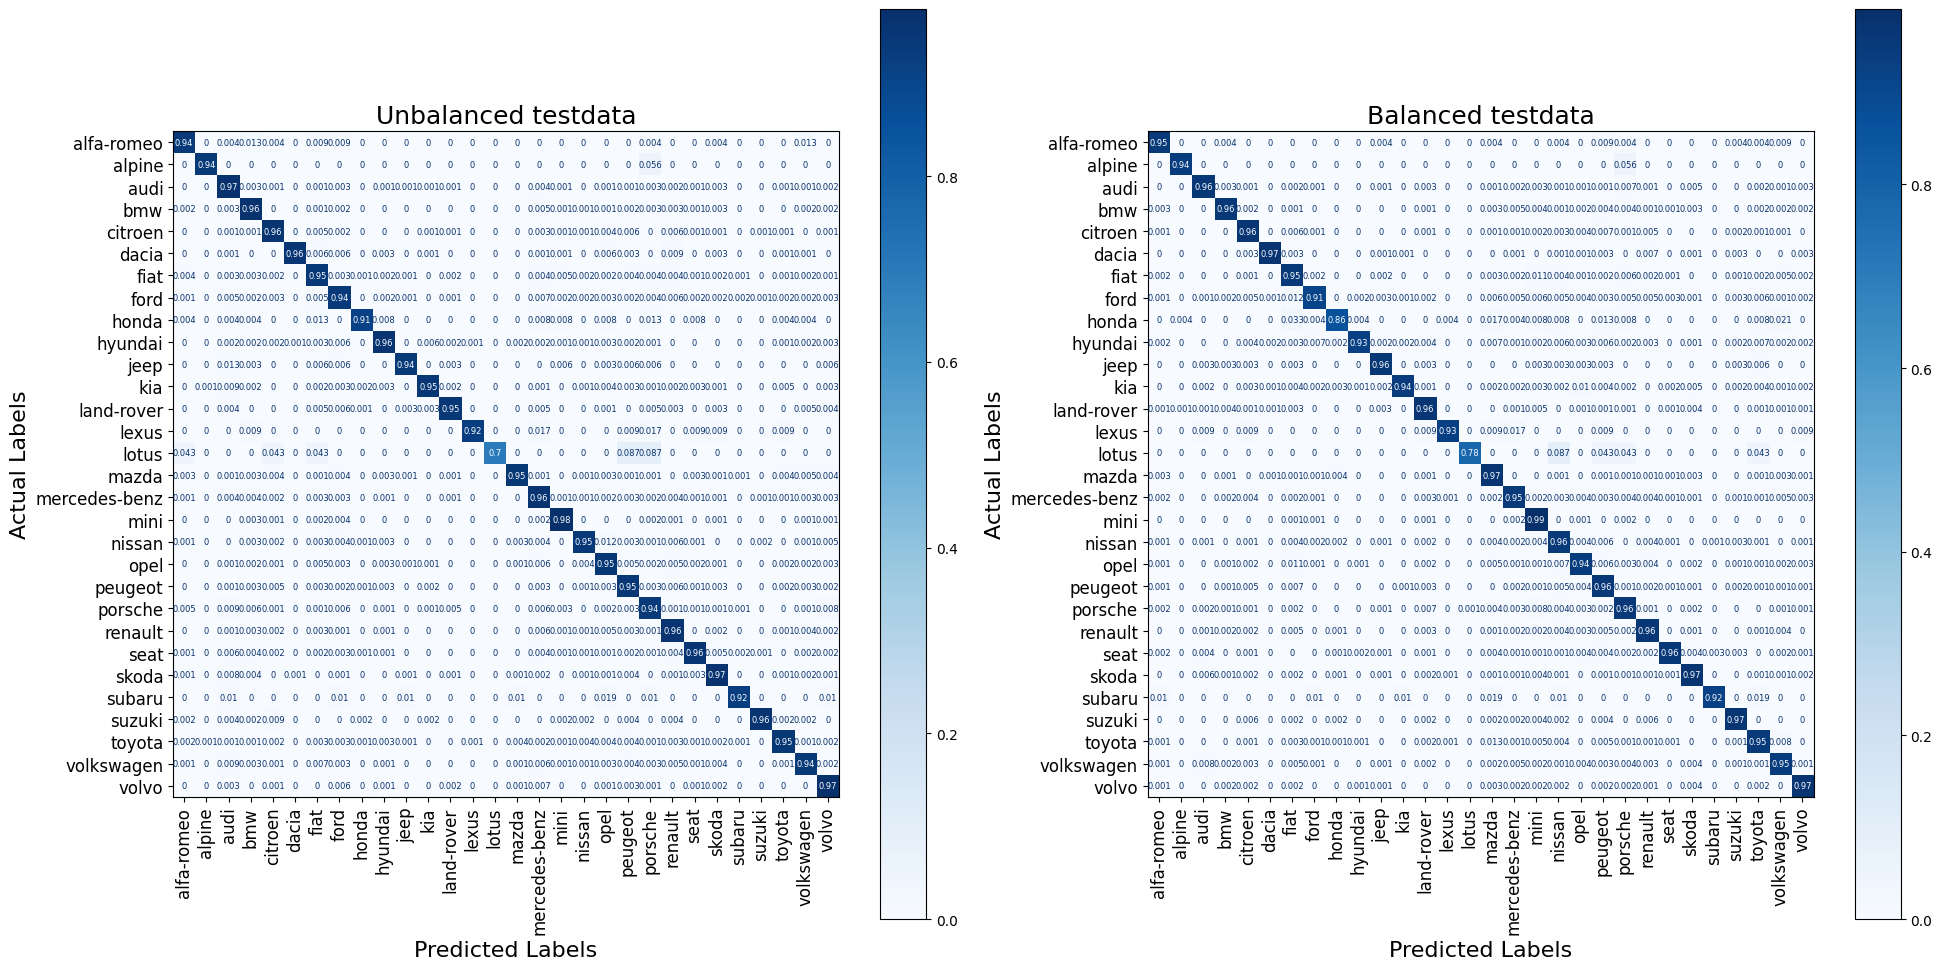

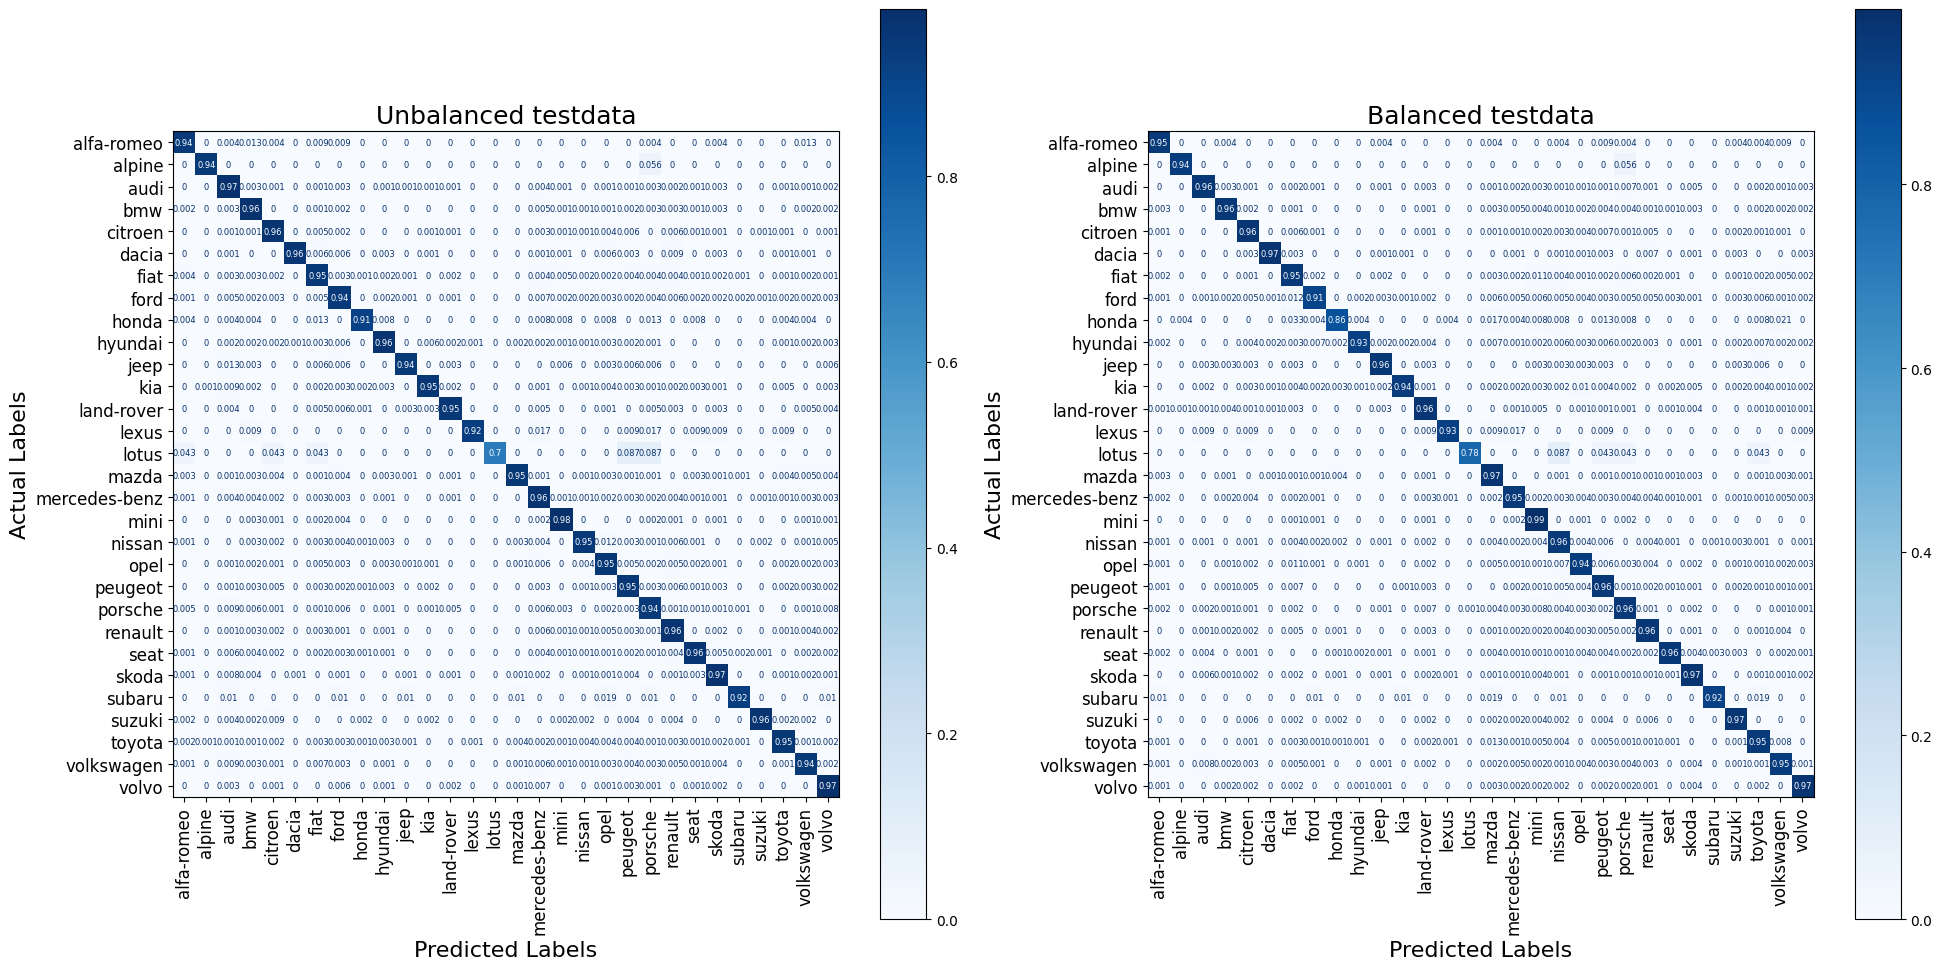

In [36]:
implot.side_by_side_cm(front_unbalanced_cm, 'Unbalanced testdata',front_balanced_cm , 'Balanced testdata')

In [128]:
brandacc = implot.brand_accuracy_plot(fua, fup)
brandacc.update_layout(title="Per-brand accuracy Unabalanced(sorted)")


In [ ]:
brandacc = implot.brand_accuracy_plot(fba, fbp)
brandacc.update_layout(title="Per-brand accuracy Balanced(sorted)")

In [130]:
misses = implot.brand_missclassification_plot(fua, fup)
misses.update_layout(title="Misclassification frequency per brand Unbalanced(errors only)")

In [132]:
misses = implot.brand_missclassification_plot(fba, fbp)
misses.update_layout(title="Misclassification frequency per brand Balanced(errors only)")

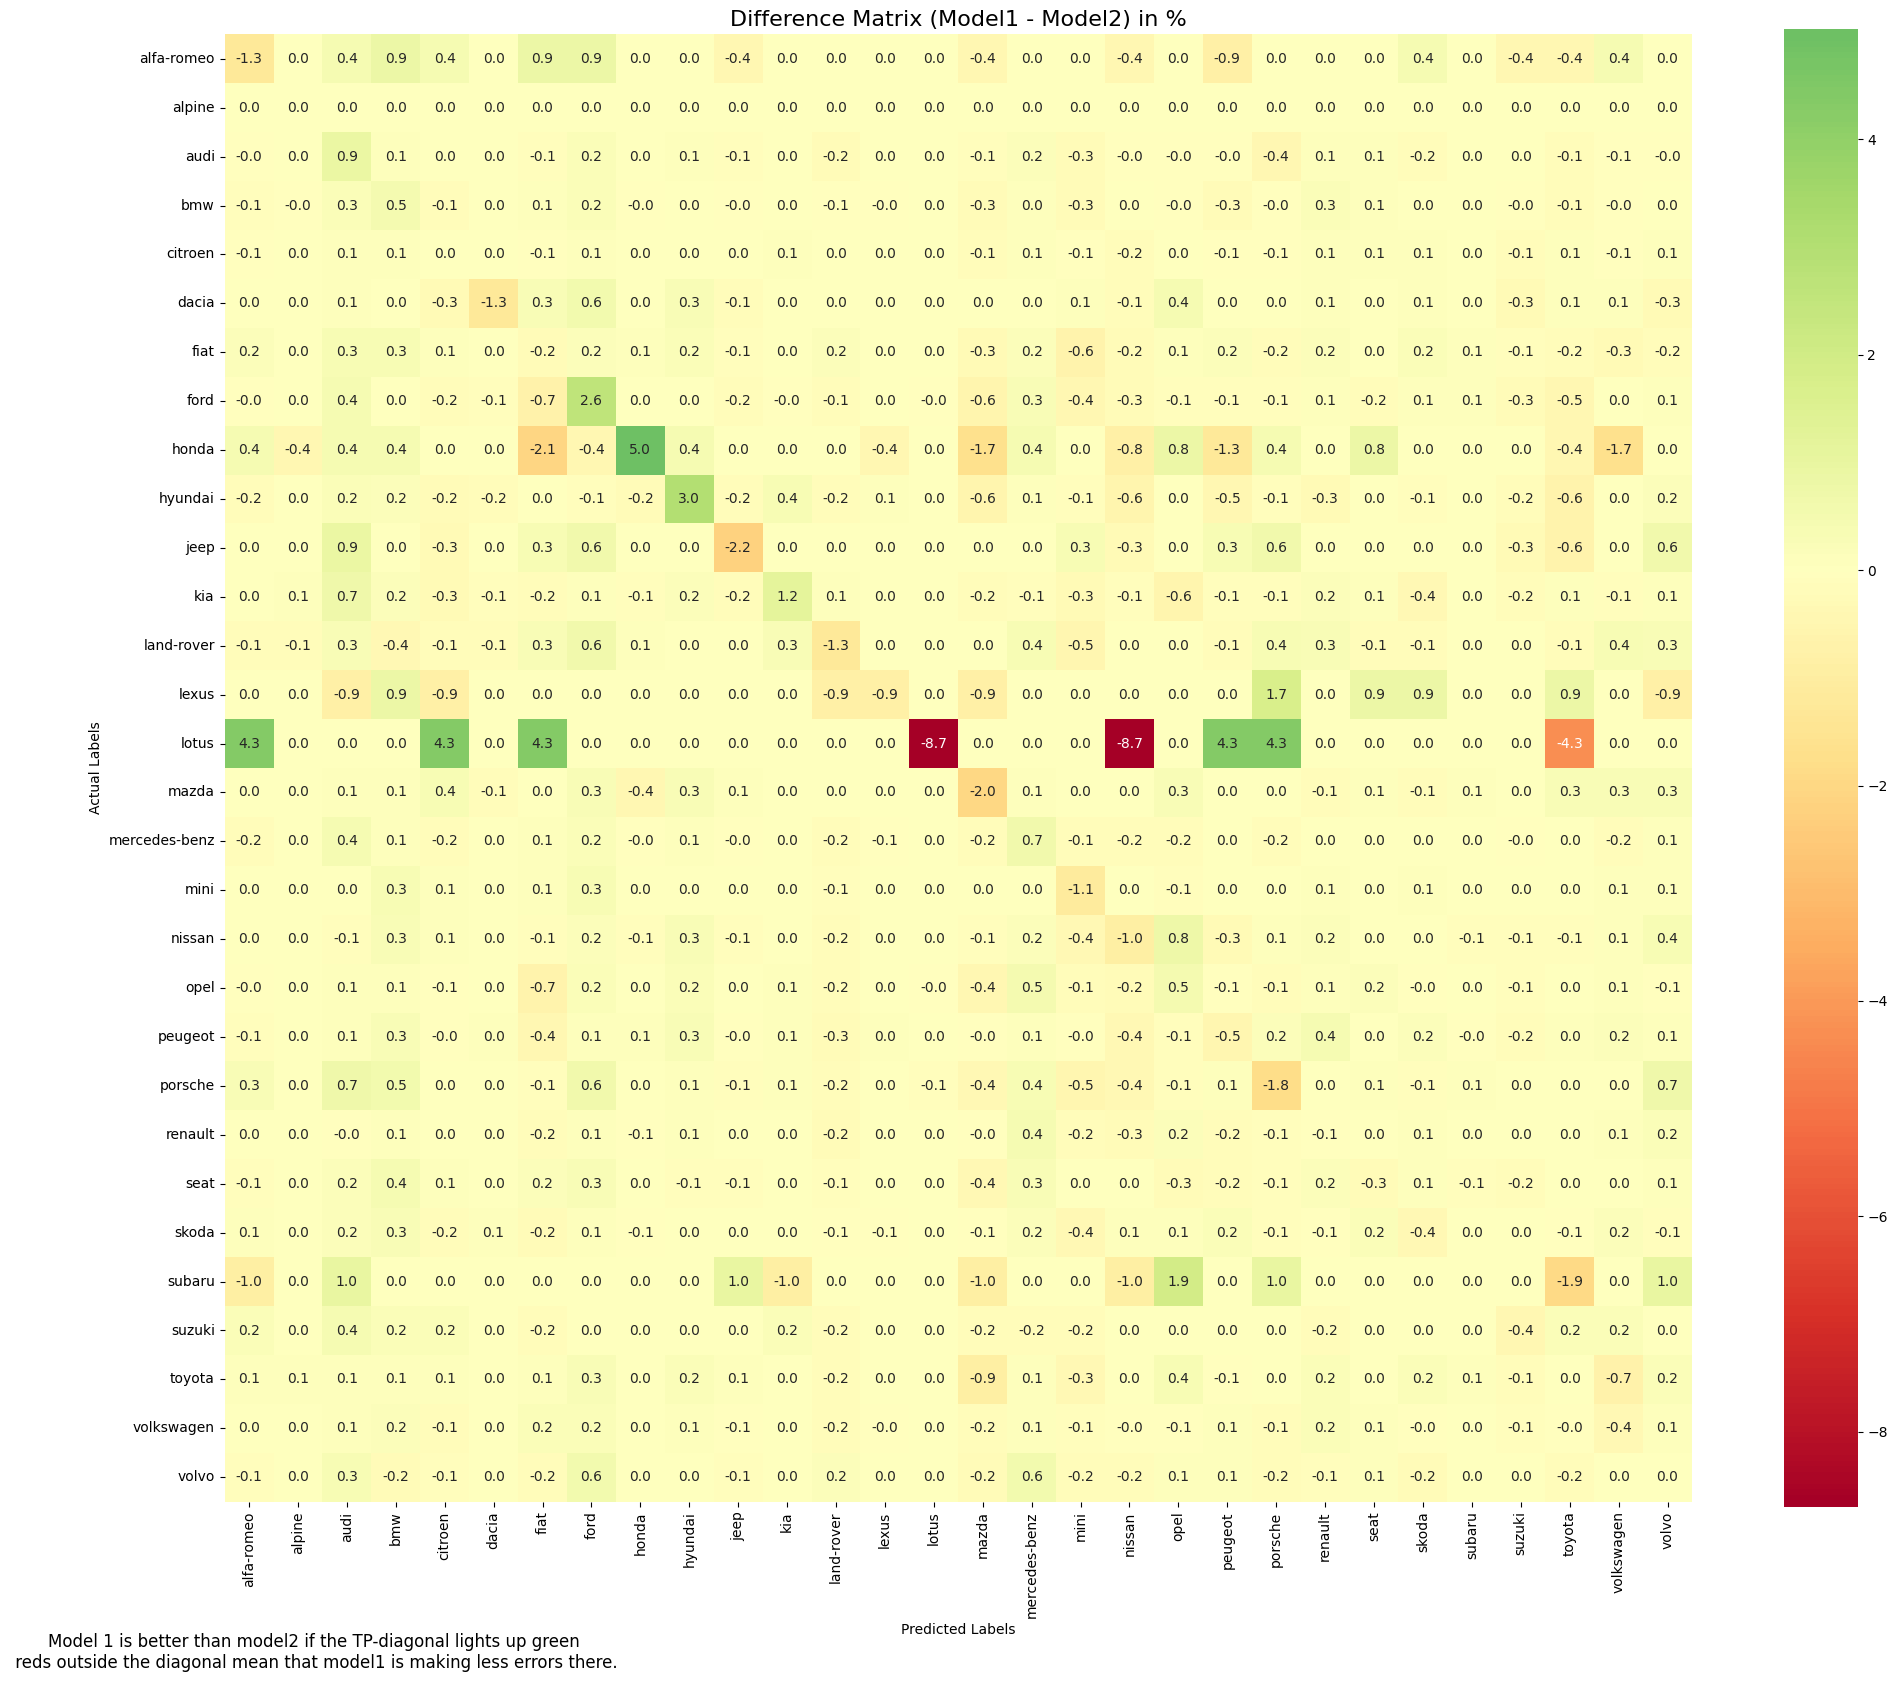

In [18]:
assert fua == fba #THIS IS THE SAME
implot.cm_delta(fup, fbp, fua, list(brand_names))#so we can use a deltaview
#the deltaview shows the absolute difference in %points not relative percentage. so a cell that goes from 0.9 to O.91 = will show as +1 (1percentpoint up.)

And make a deltamatrix: 

side by side comparison is not that clear from a glance, let's use the quickmetrics of both: 

In the plots above model1 is the set trained without balancing out the test dataset; model2 was trained on exactly the same traindata, but with fully equalized testdata. 
- Green on the diagonal line = better performance of model1 than model 2
- Red on the diagonal line = better performance of model2 than model 1
- Green outside of diagonal line = better performance of model2 than model 1
- Red outside of diagonal line = better performance of model1 than model2

==> it's a close call; let's focus on the actual diagonal: 

In [19]:
#Let's visualize that observation with a more clear plot. 
textObjects = {
    'title': 'Difference of balanced vs unbalanced testdata during training.',
    'xaxis_title': 'Accuracy difference in percentpoints',
    'yaxis_title': 'Brands'
}

implot.compare_model_accuracies(fup, fua, fbp, fba, list(brand_names),textObjects)

and let's now focus on the gathered metrics. 

In [20]:
fig = implot.plot_quick_metrics(full_metrics_balance)
fig.update_layout(
    height=800,
    width=1400,
    title_text='Training front angle of dataset on balanced vs unbalanced testset (same traindata)',
    showlegend=False
)


The difference is negligeble, so this matters less than thought.

## 3.6.5 Vision Transformer vs CNN(transfer learned)
The front angle was also used to experiment with and asses the difference in performance between a Vision transformer and a traditional CNN. There's reason to believe ViTs might perform better. These architecture are less prone to missing their target if a small part of the image is obscured by 'noise' (e.g. visual obstruction between the camera and object)

In this phase we'll compare the performance of ViT architecture vs CNN architecture using the view from the front. The ViT model was trained on a fully balanced train- and test dataset. The trainset was the same for each model, the testset was the same with the exception for undersampled brands where instances might not be shared. 

Note that we do not need to infer the same model from 3.6.4 again, we just extend `full_metrics_balance` into a new variable with the ViT infer results added to it. 

In [42]:
angle_to_asses = 'front'

full_metrics_balance_and_vit = full_metrics_balance

#we reuse fua, fup , fba, fbp from above. Just do the ezcompar on vit results: 
data = results['ViT_models']
vitfa, vitfp = data[angle_to_asses]['actuals'], decode_labels(data[angle_to_asses]['decoder'], data[angle_to_asses]['predicts'])

front_vit_cm, front_vit_metrics = ez_compare(vitfa, vitfp, brand_names)

full_metrics_balance_and_vit['VIT'] =  front_vit_metrics



In [51]:
fig = implot.plot_quick_metrics(full_metrics_balance_and_vit)
fig.update_layout(
    height=800,
    width=1400,
    title_text='Training front angle of dataset on balanced vs unbalanced testset (same traindata) vs ViT',
    showlegend=False
)


Ouch, ViT performs poorer across the board

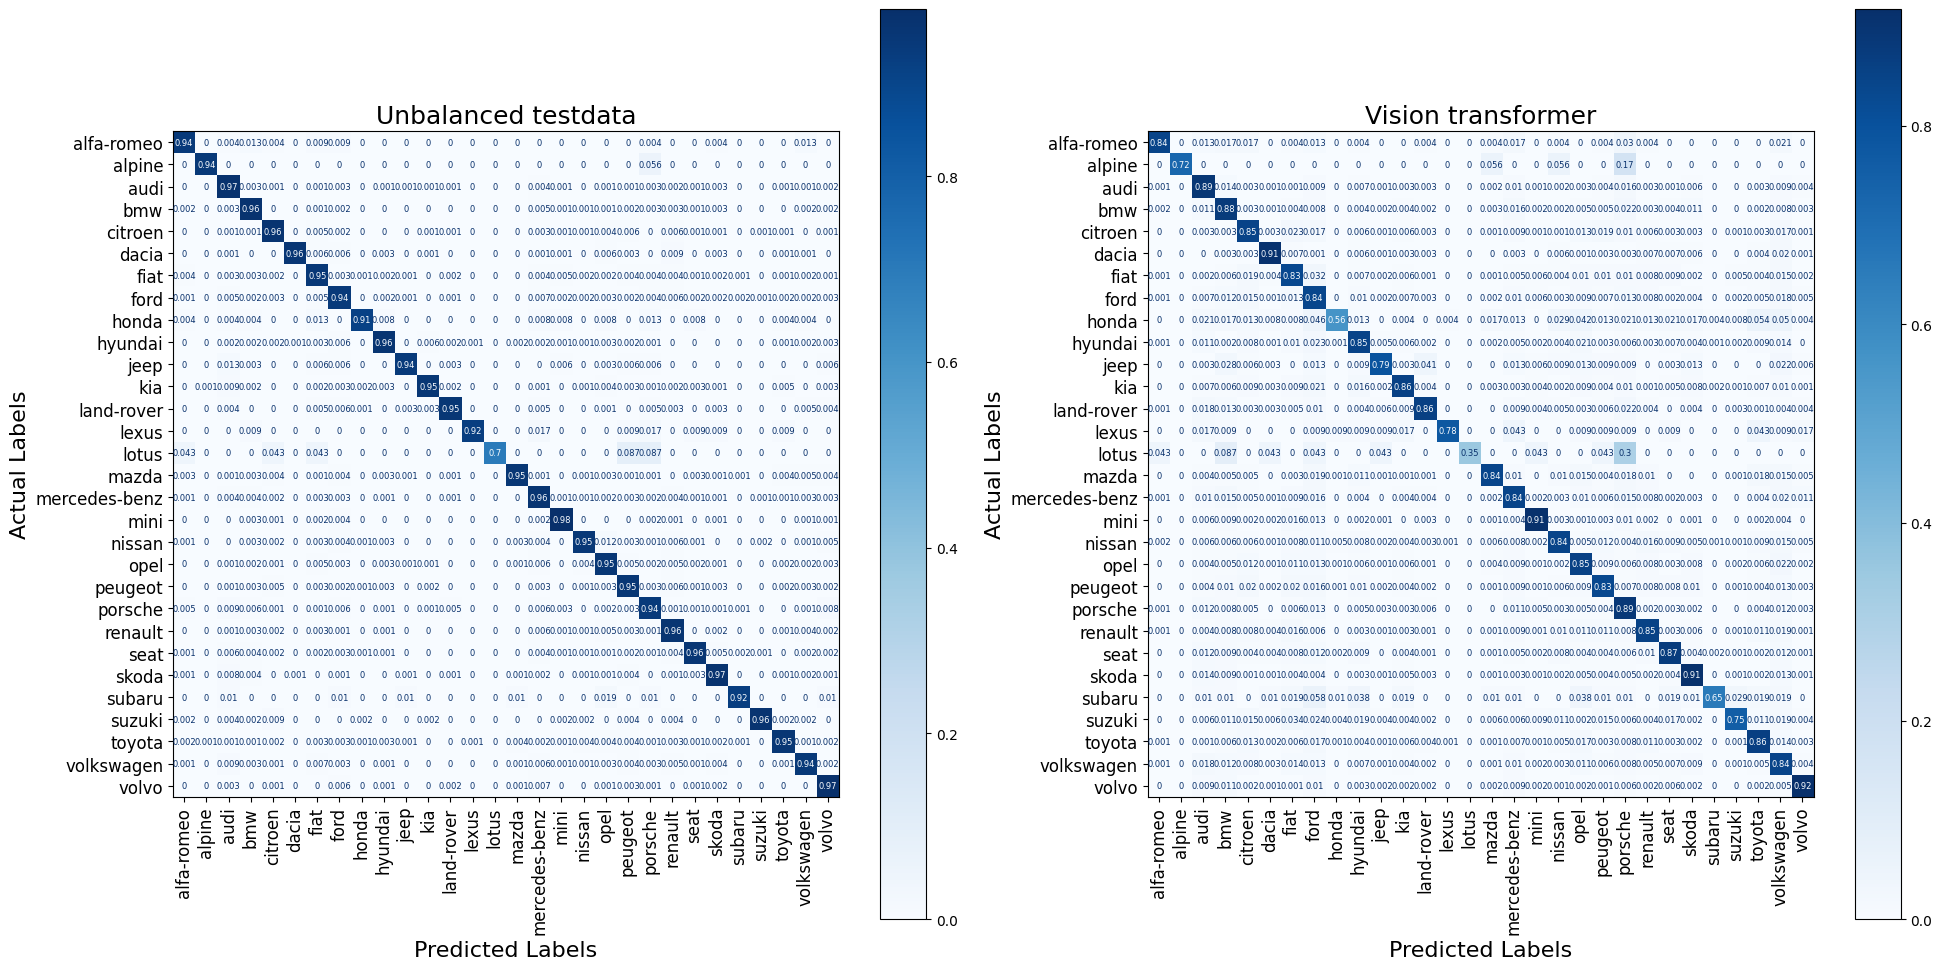

In [44]:
implot.side_by_side_cm(front_unbalanced_cm, 'Unbalanced testdata',front_vit_cm , 'Vision transformer')


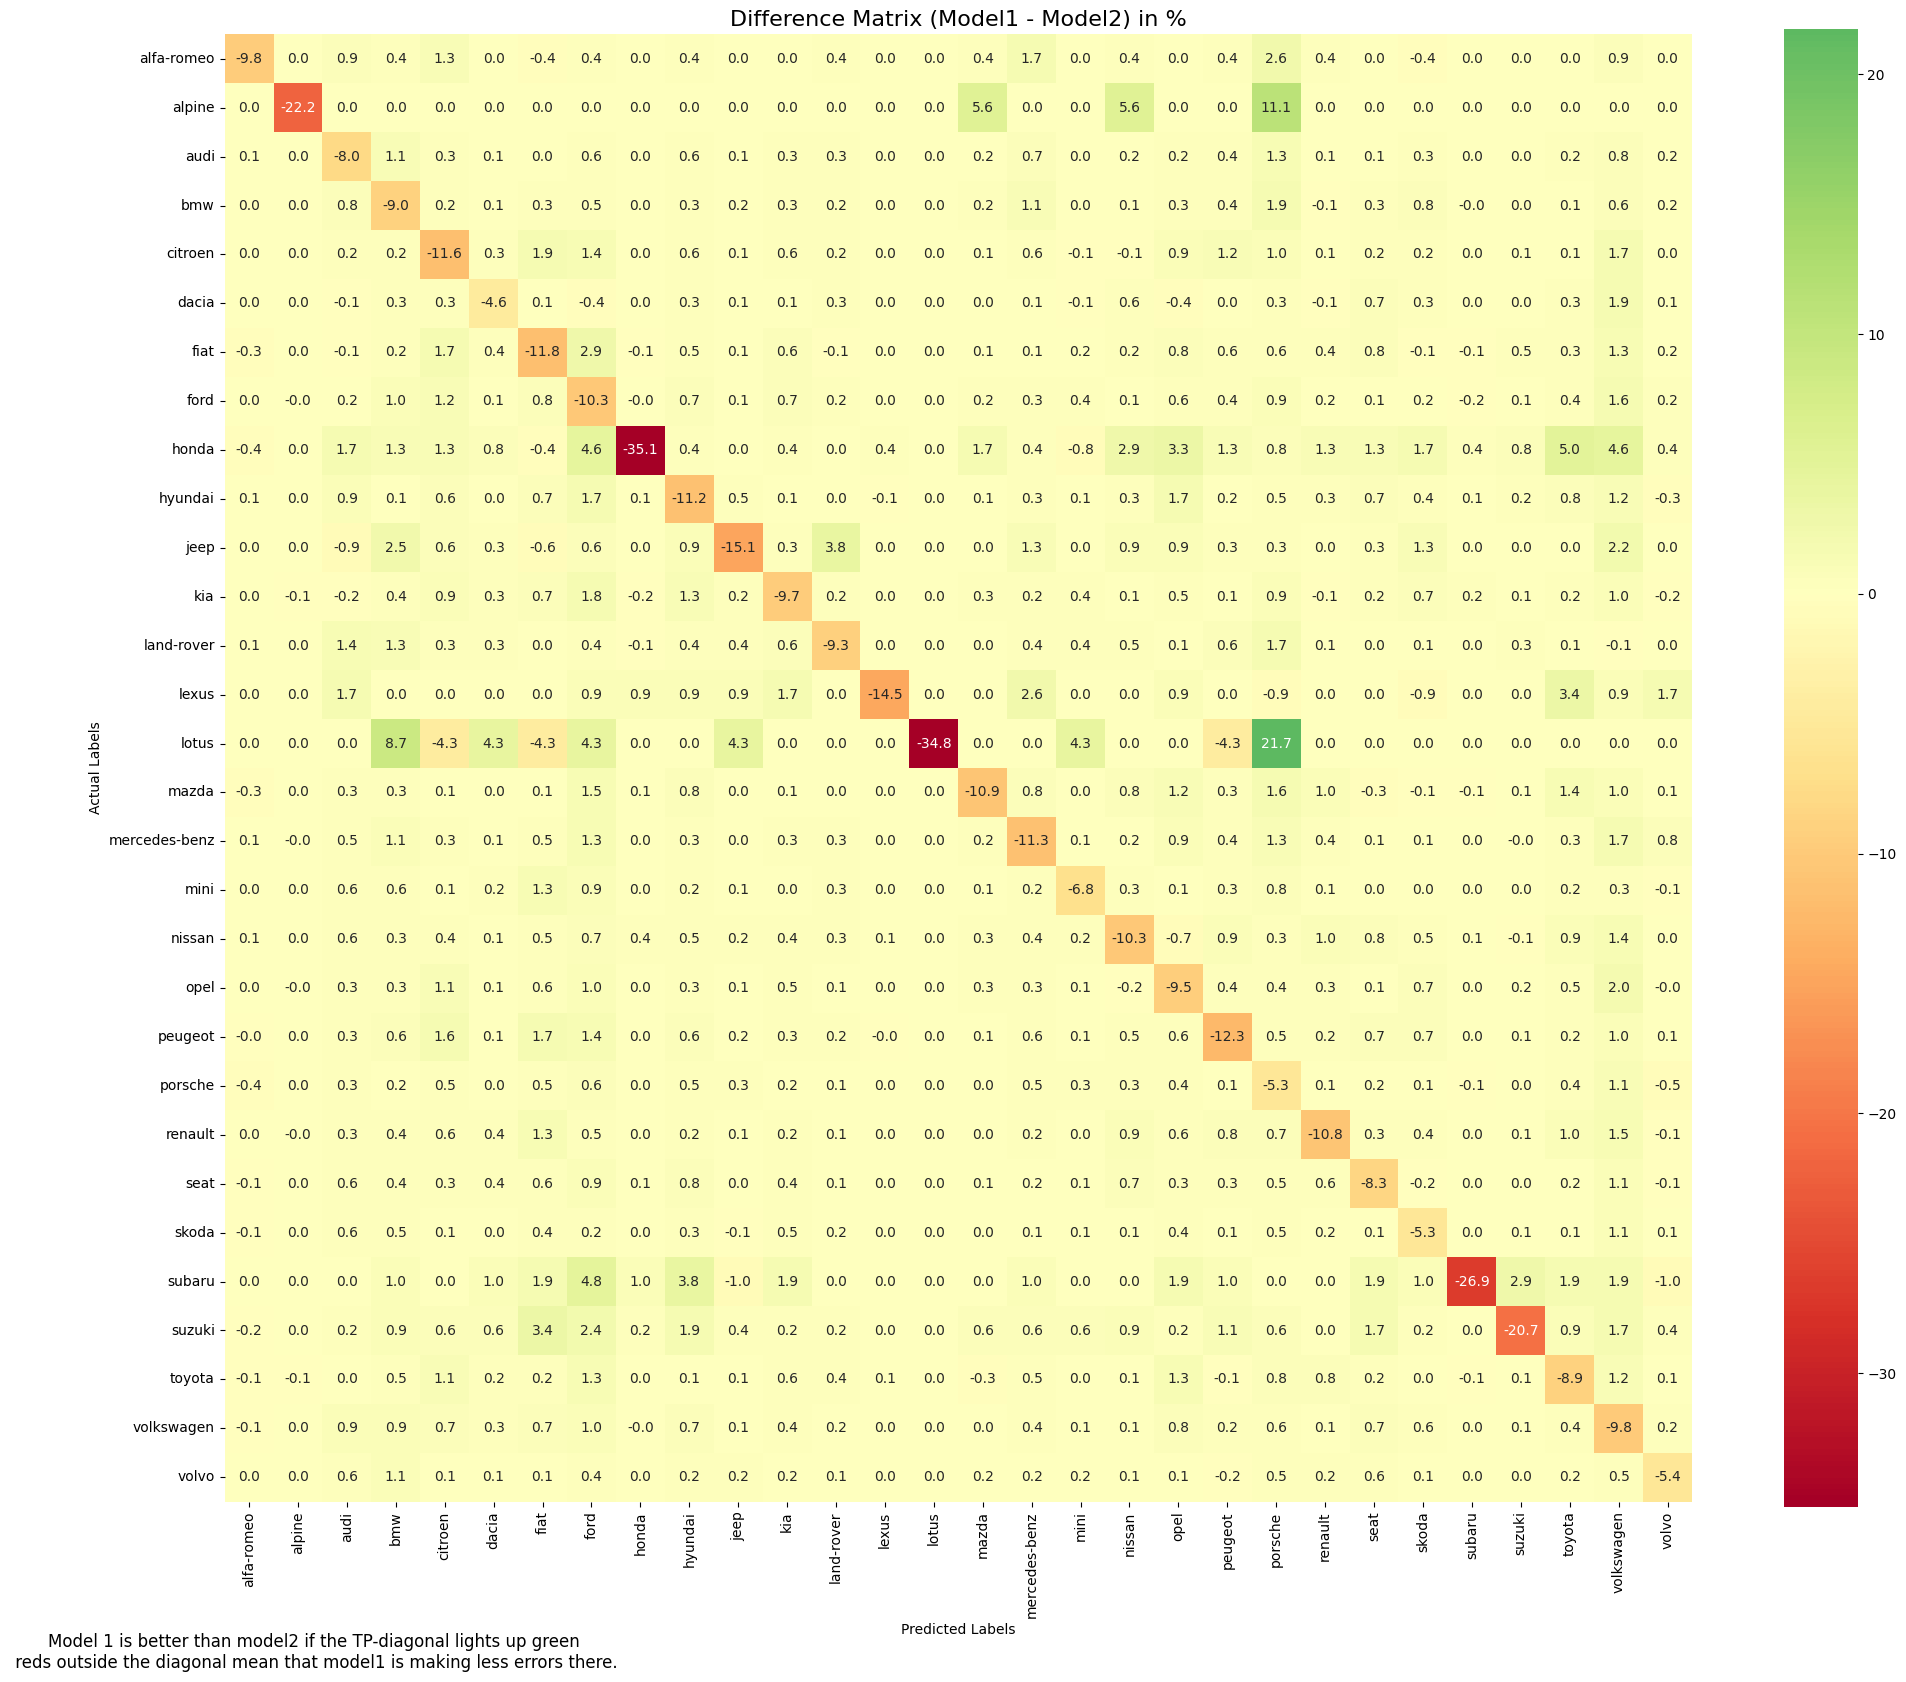

In [50]:
#check the delta: unbalance vs Vision Transformer 
implot.cm_delta(vitfp, fup, fua, list(brand_names))

Based on this CM_delta plot, we get the suspicion that low-frequency brands are performing relatively worse than high-frequency brands

In [ ]:
brandacc = implot.brand_accuracy_plot(fba, fbp)
brandacc.update_layout(title="Per-brand accuracy CNN-Unbalanced(sorted)")

brandacc = implot.brand_accuracy_plot(fba, fbp)
brandacc.update_layout(title="Per-brand accuracy ViT(sorted)")


In [ ]:
misses = implot.brand_missclassification_plot(fua, fup)
misses.update_layout(title="Misclassification frequency per brand CNN-Unbalanced(errors only)")
misses = implot.brand_missclassification_plot(fua, fup)
misses.update_layout(title="Misclassification frequency per brand ViT(errors only)")

In [49]:
textObjects = {
    'title': 'Difference of ViT vs CNN on frontangle.',
    'xaxis_title': 'Accuracy difference in percentpoints',
    'yaxis_title': 'Brands'
}

implot.compare_model_accuracies(vitfp, vitfa, fup, fua, list(brand_names),textObjects)

Scratch that thought: Look at Alfa Romeo vs Mercedes. Dacia is at the top: and it is also not very common

A possible explanation could be the internal variation of each brand. We have 'model'labels in SQL, but these are not very accurate
i.e. All VW Golfs are labelled as model Golf; That's not sufficient to assess the model variations: 
- The VW Golf has 8 generations  (MK-designation) 1st gen: 1974|1983|1991|1997|2003|2008|2012|2020
- Different body styles are available in different generations: 
    - Golf Cabrio
    - Golf MK3 ==> First Wagon versions (Golf variant)

- This holds true for almost all models in the SQL-dataset. I'm not investigating this further. 

I'm not fully convinced by this explanation as this variation withing models is not very high in brands like Alfa Romeo or Mazda   

In any case, to investigate this, one should run the `autodoc scraper.ipynb` notebook and then use a rule-based approach to match the output from the Autodoc database to the labels used in Autoscout. Beware, that these labels don't match 1 to 1 and that some caution is required in interpreting this. Once done, you can make a real assesment of model-variation based on the chassis/body-codes recovered from Autodoc.

## 3.6.6 Pooling 8 models vs full model

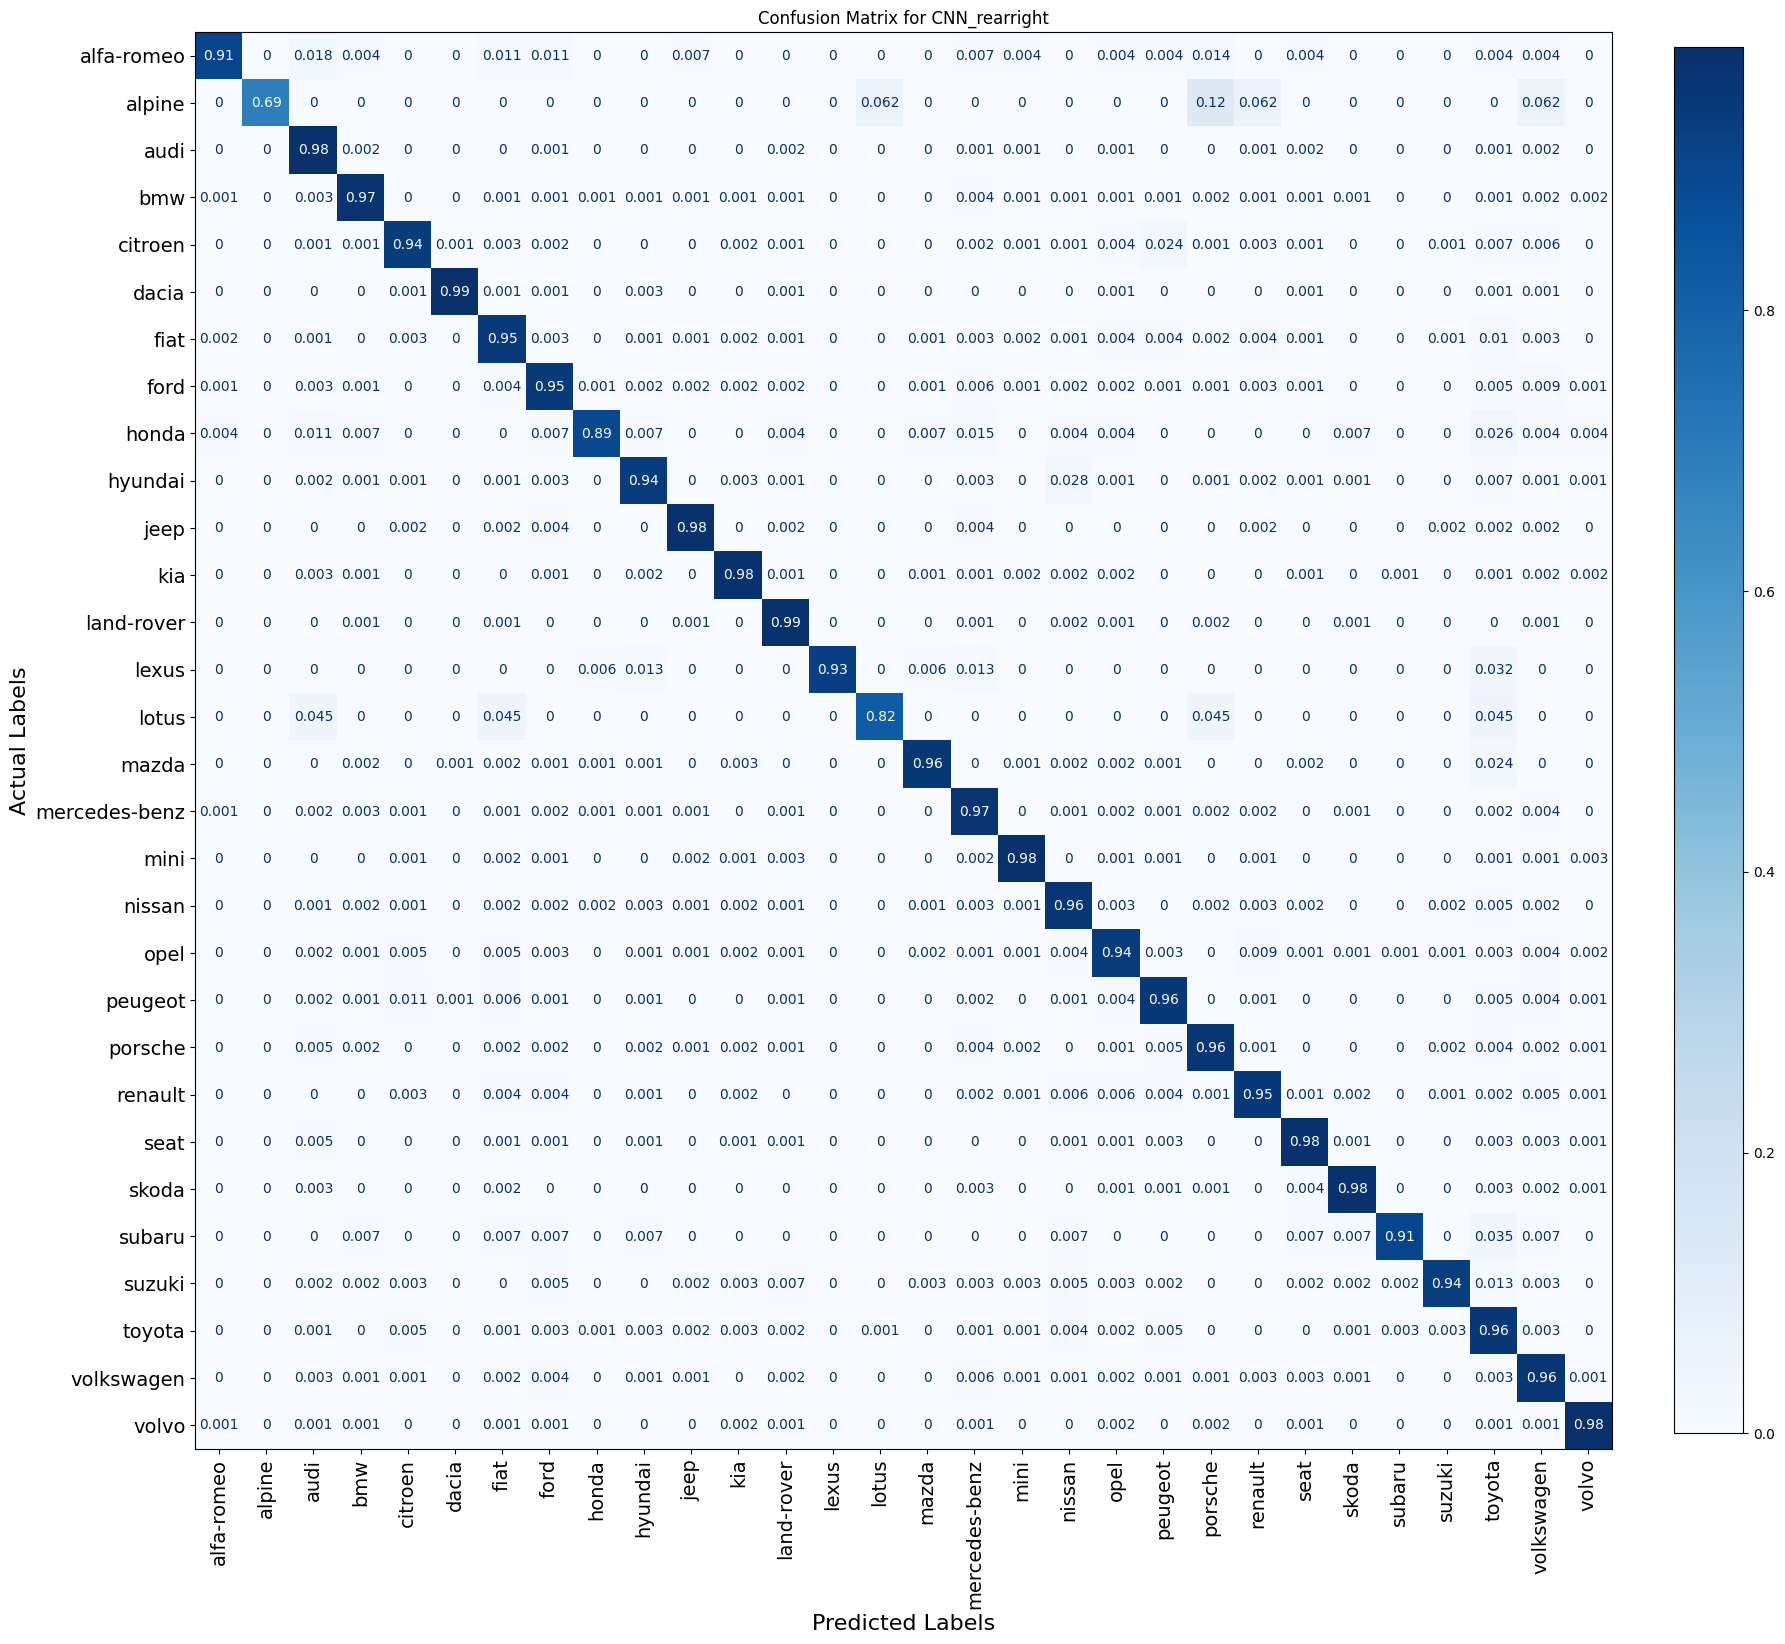

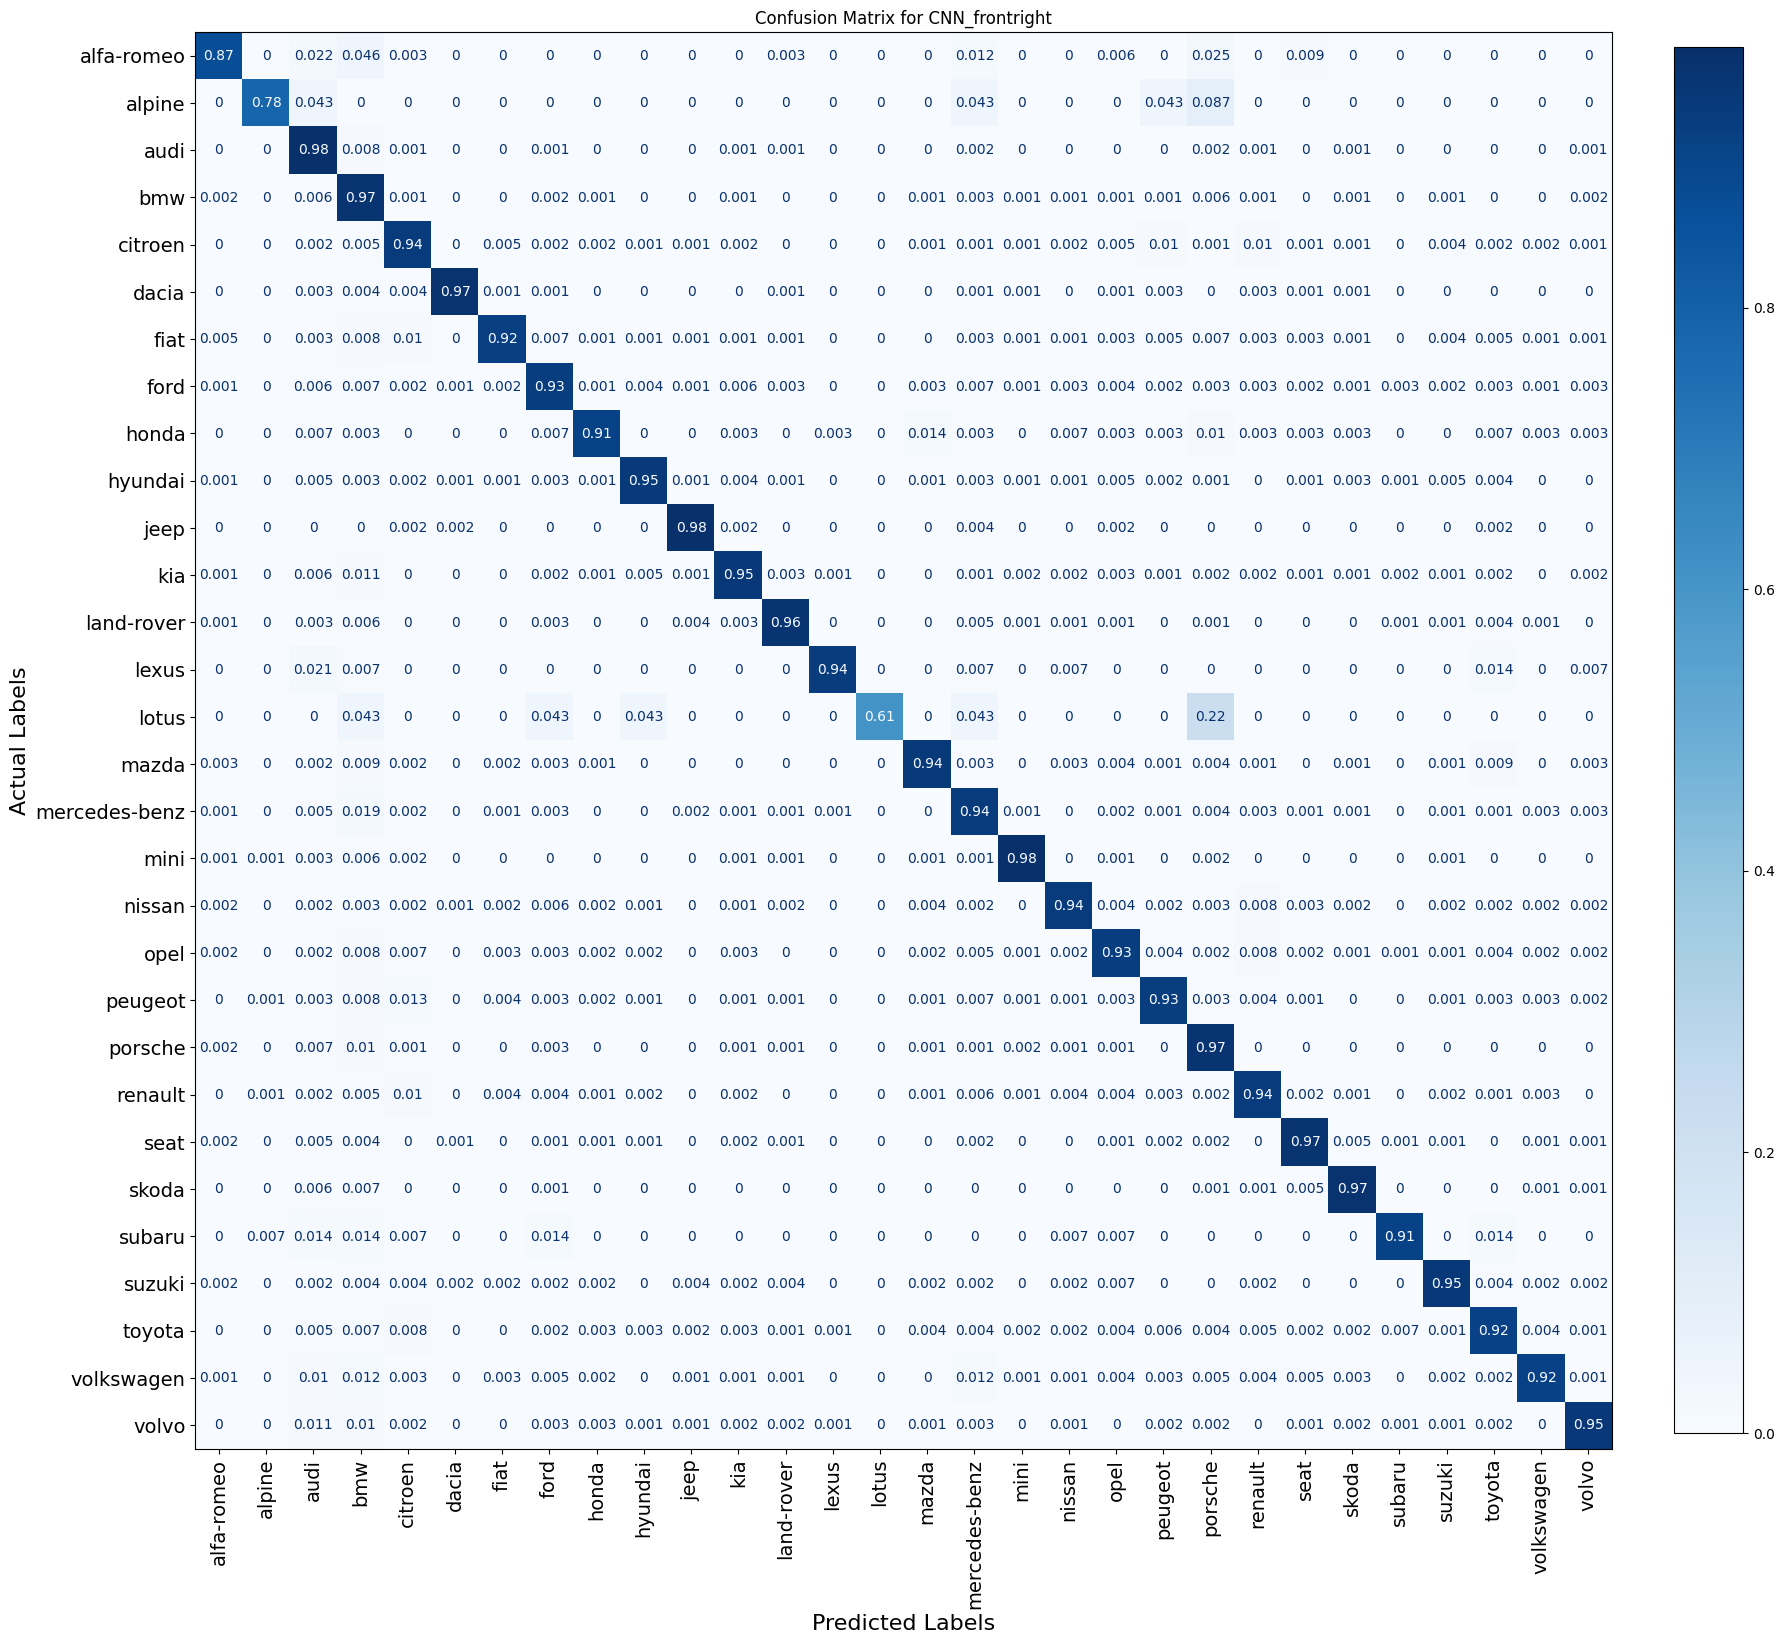

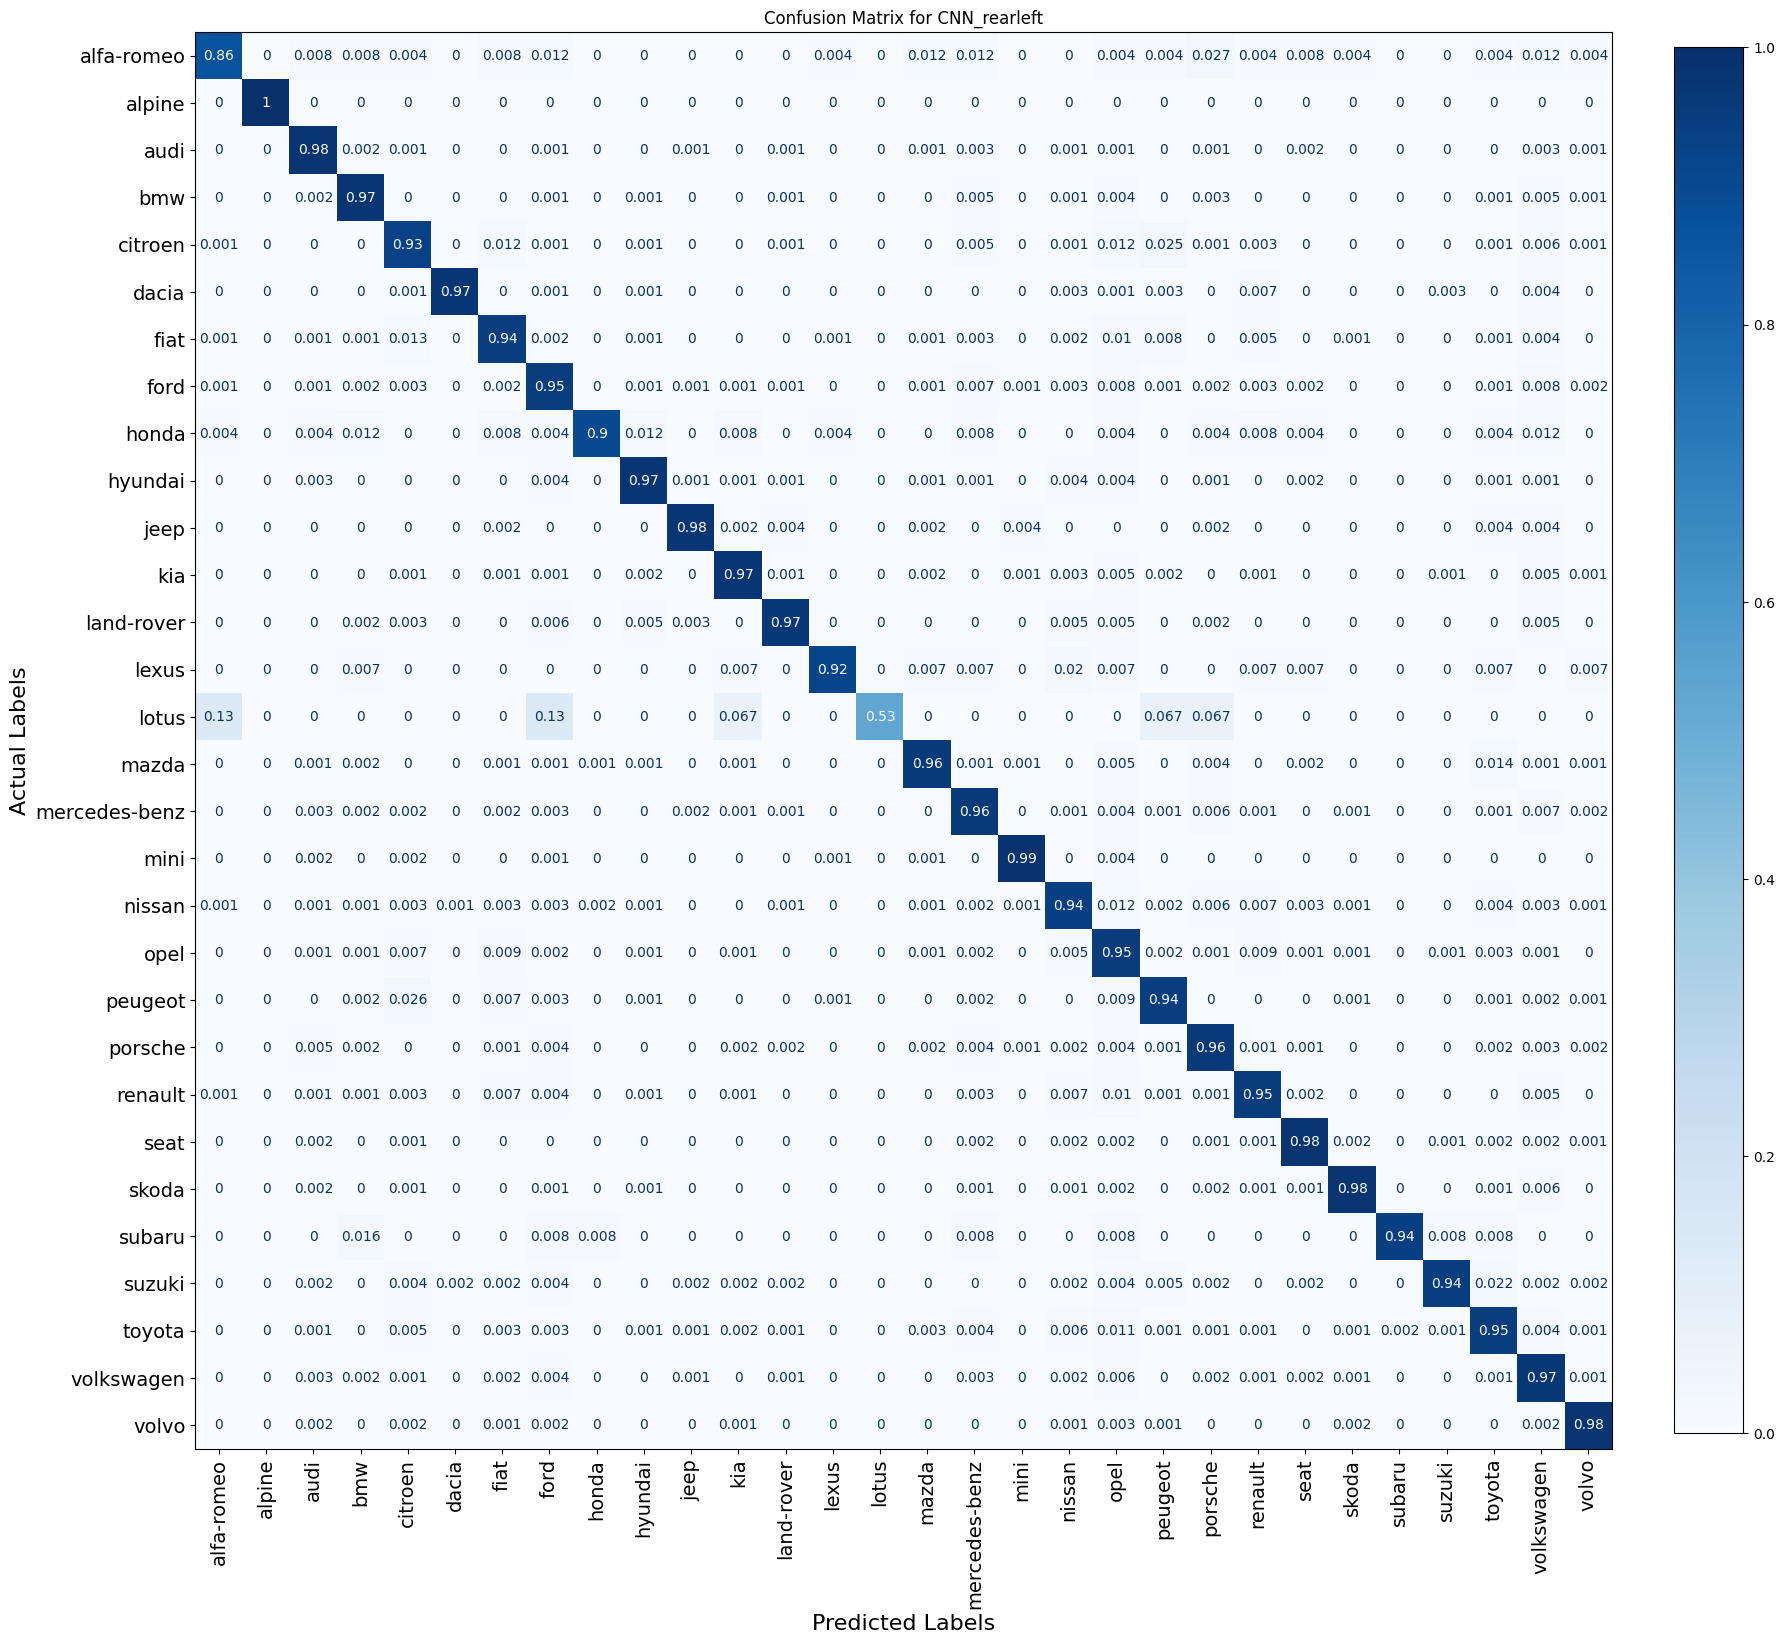

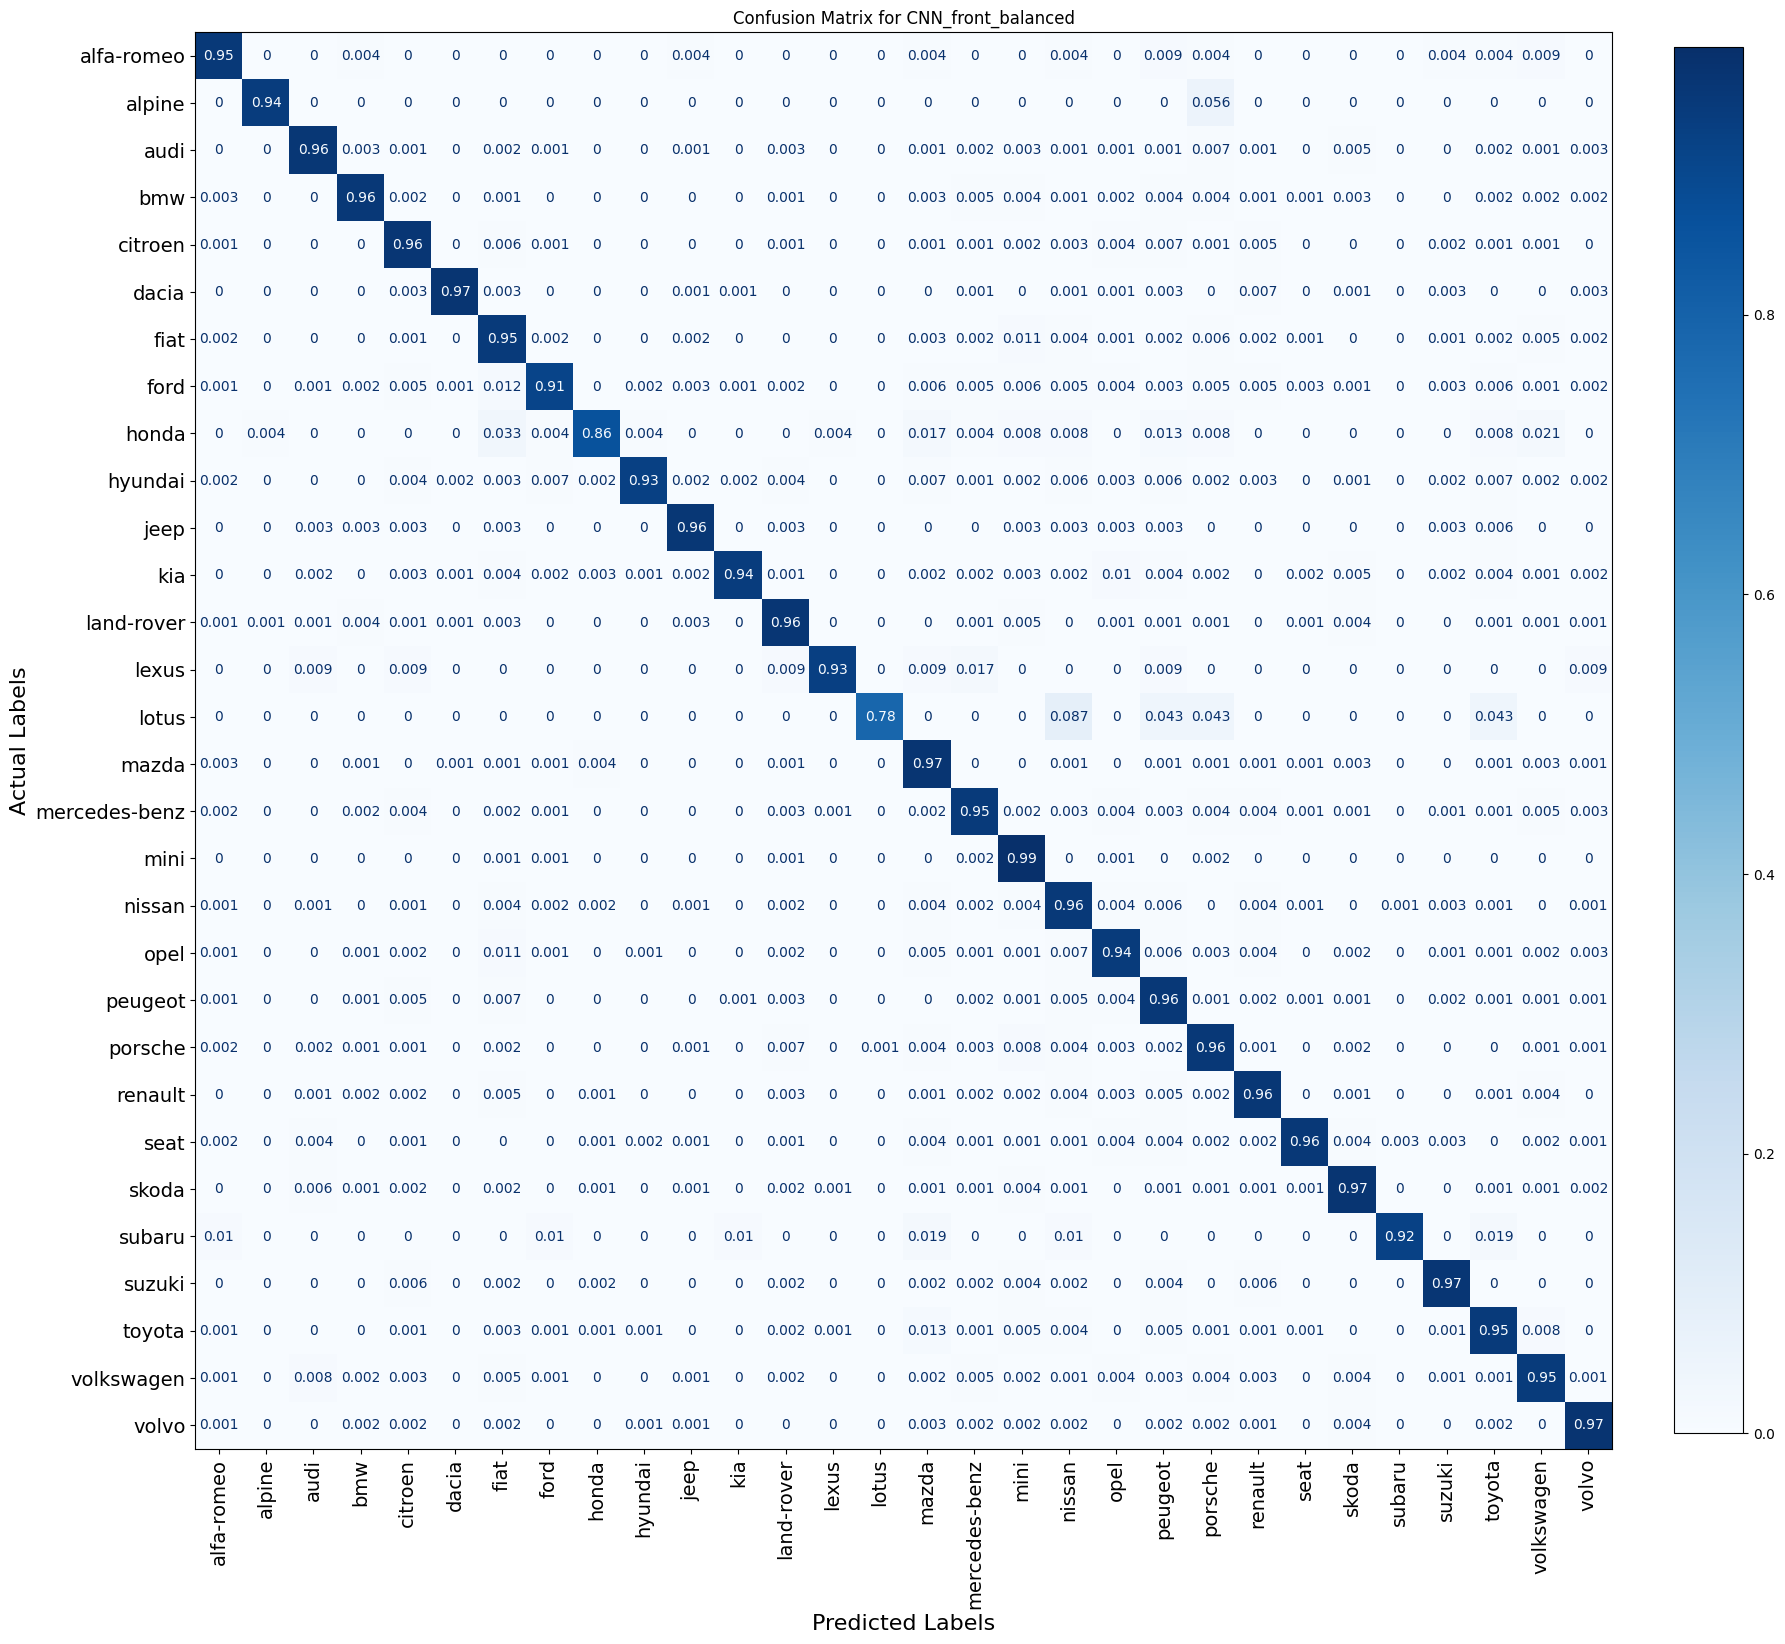

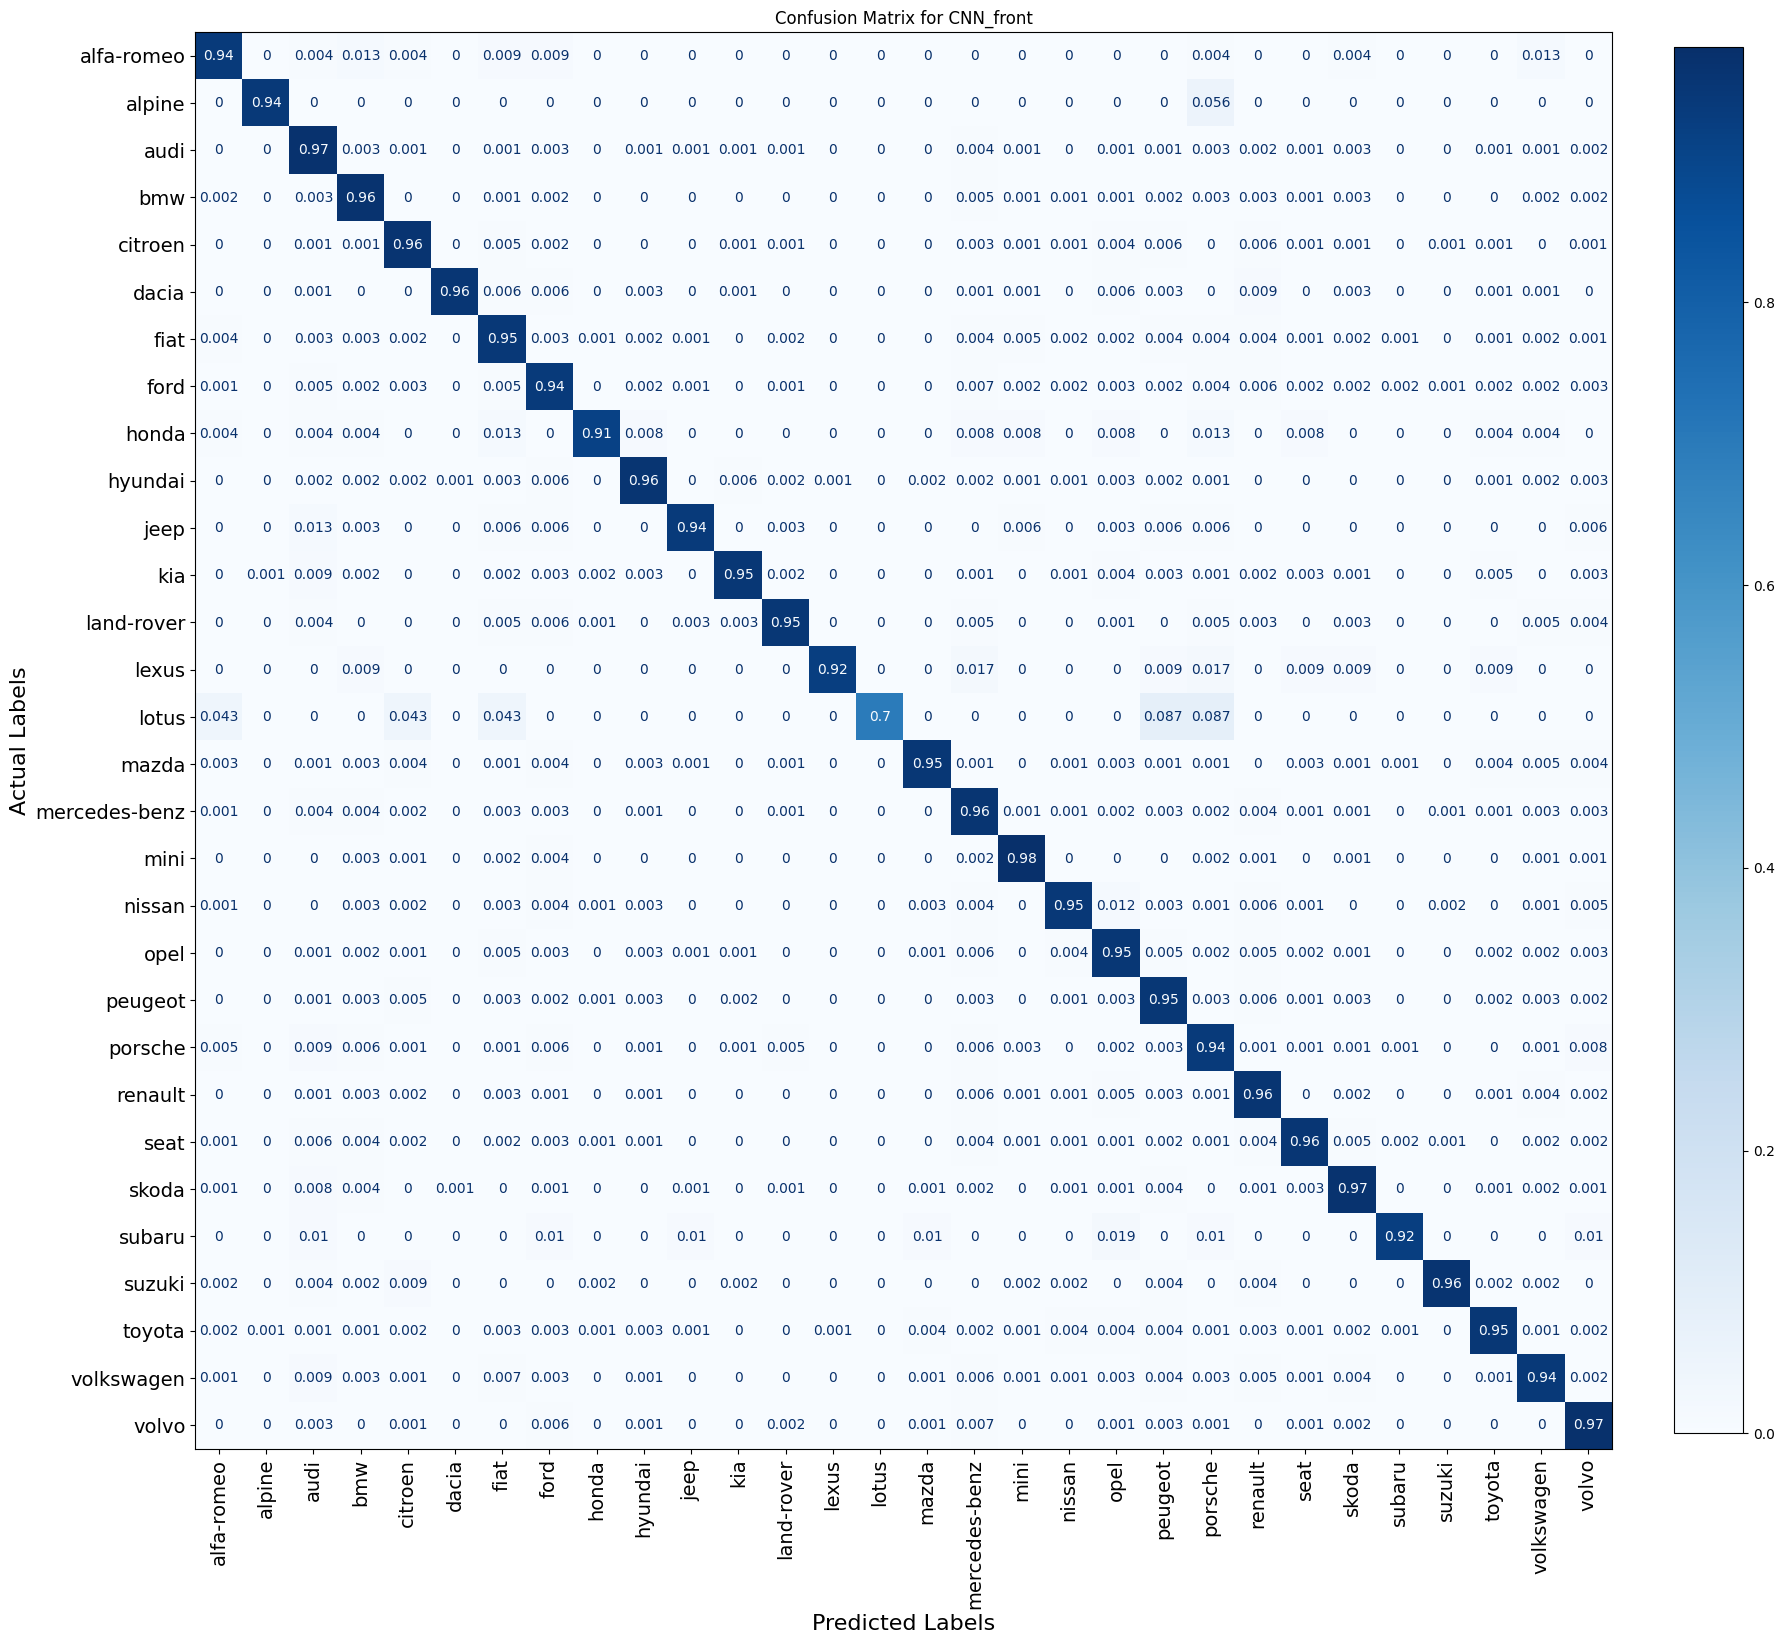

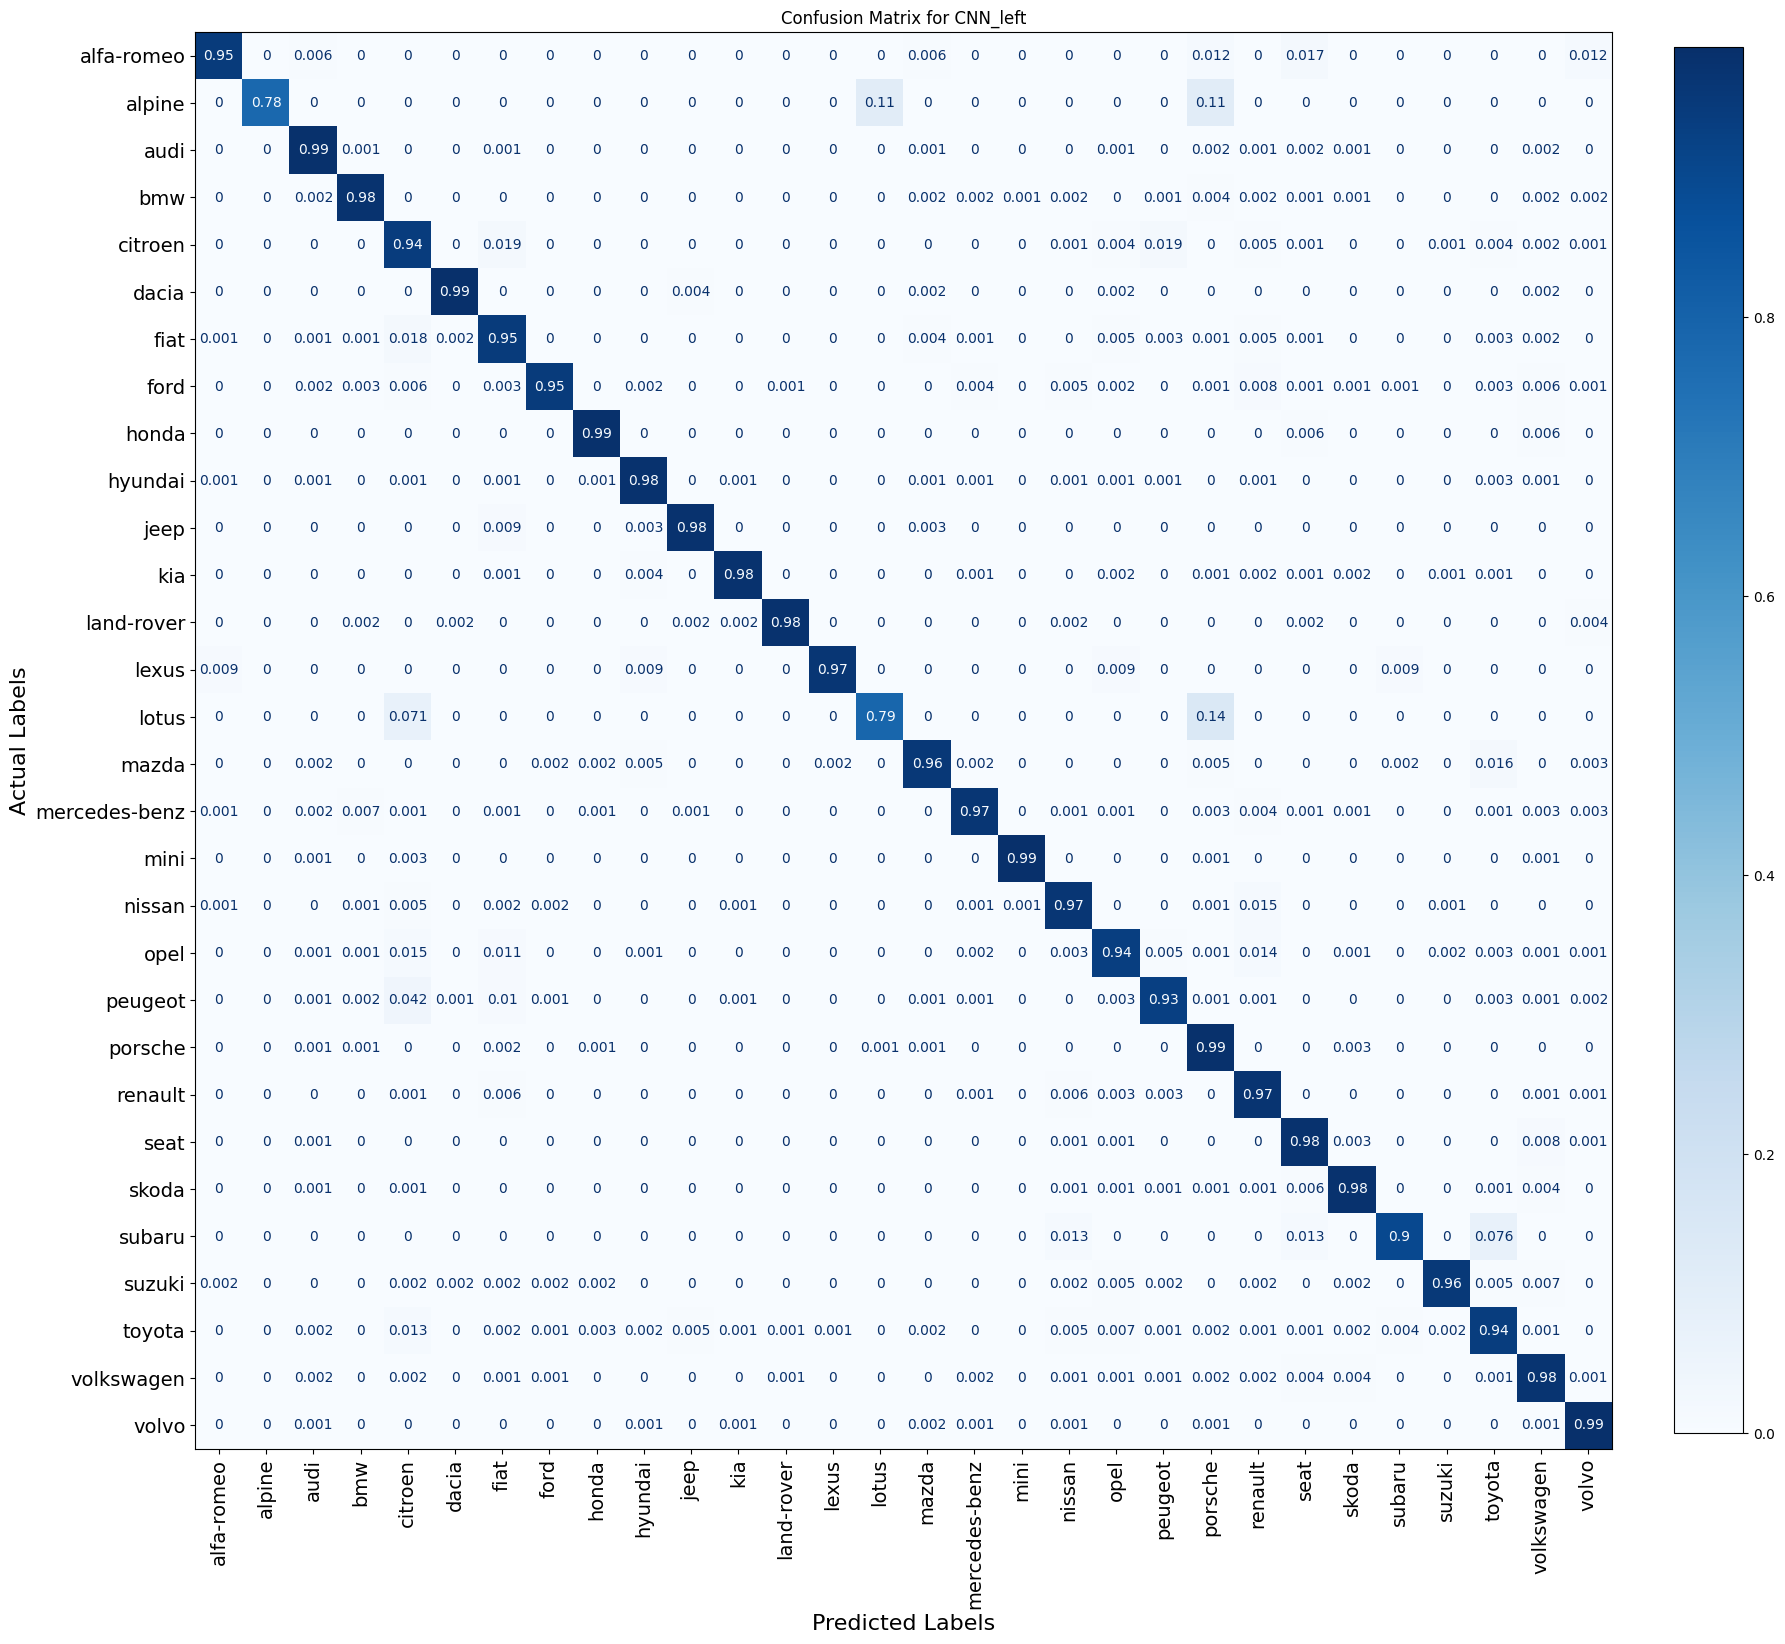

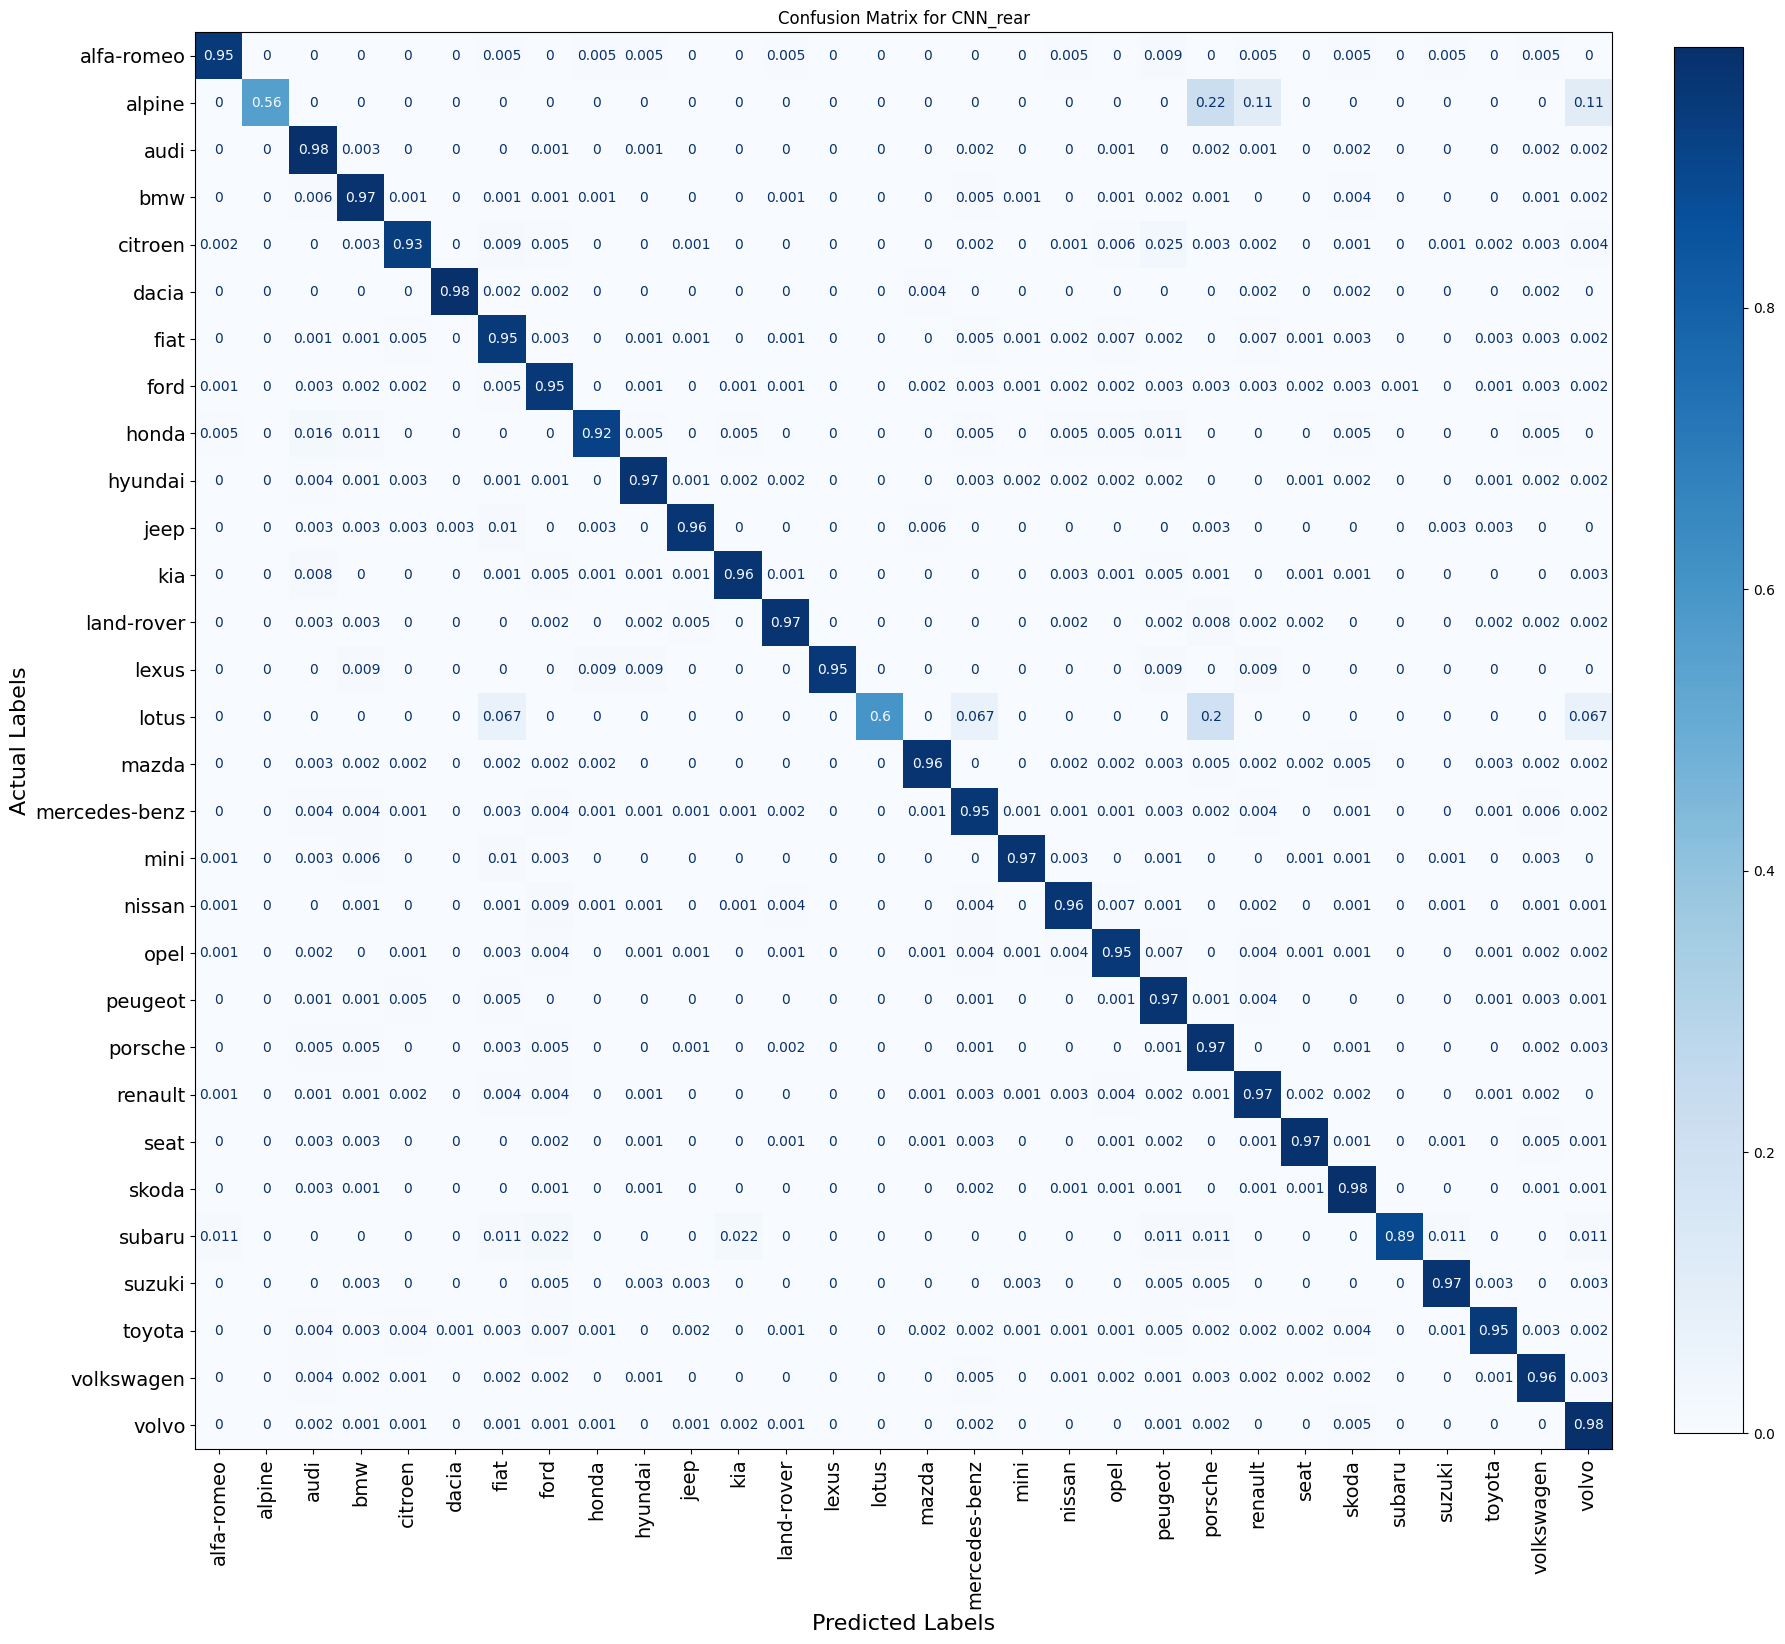

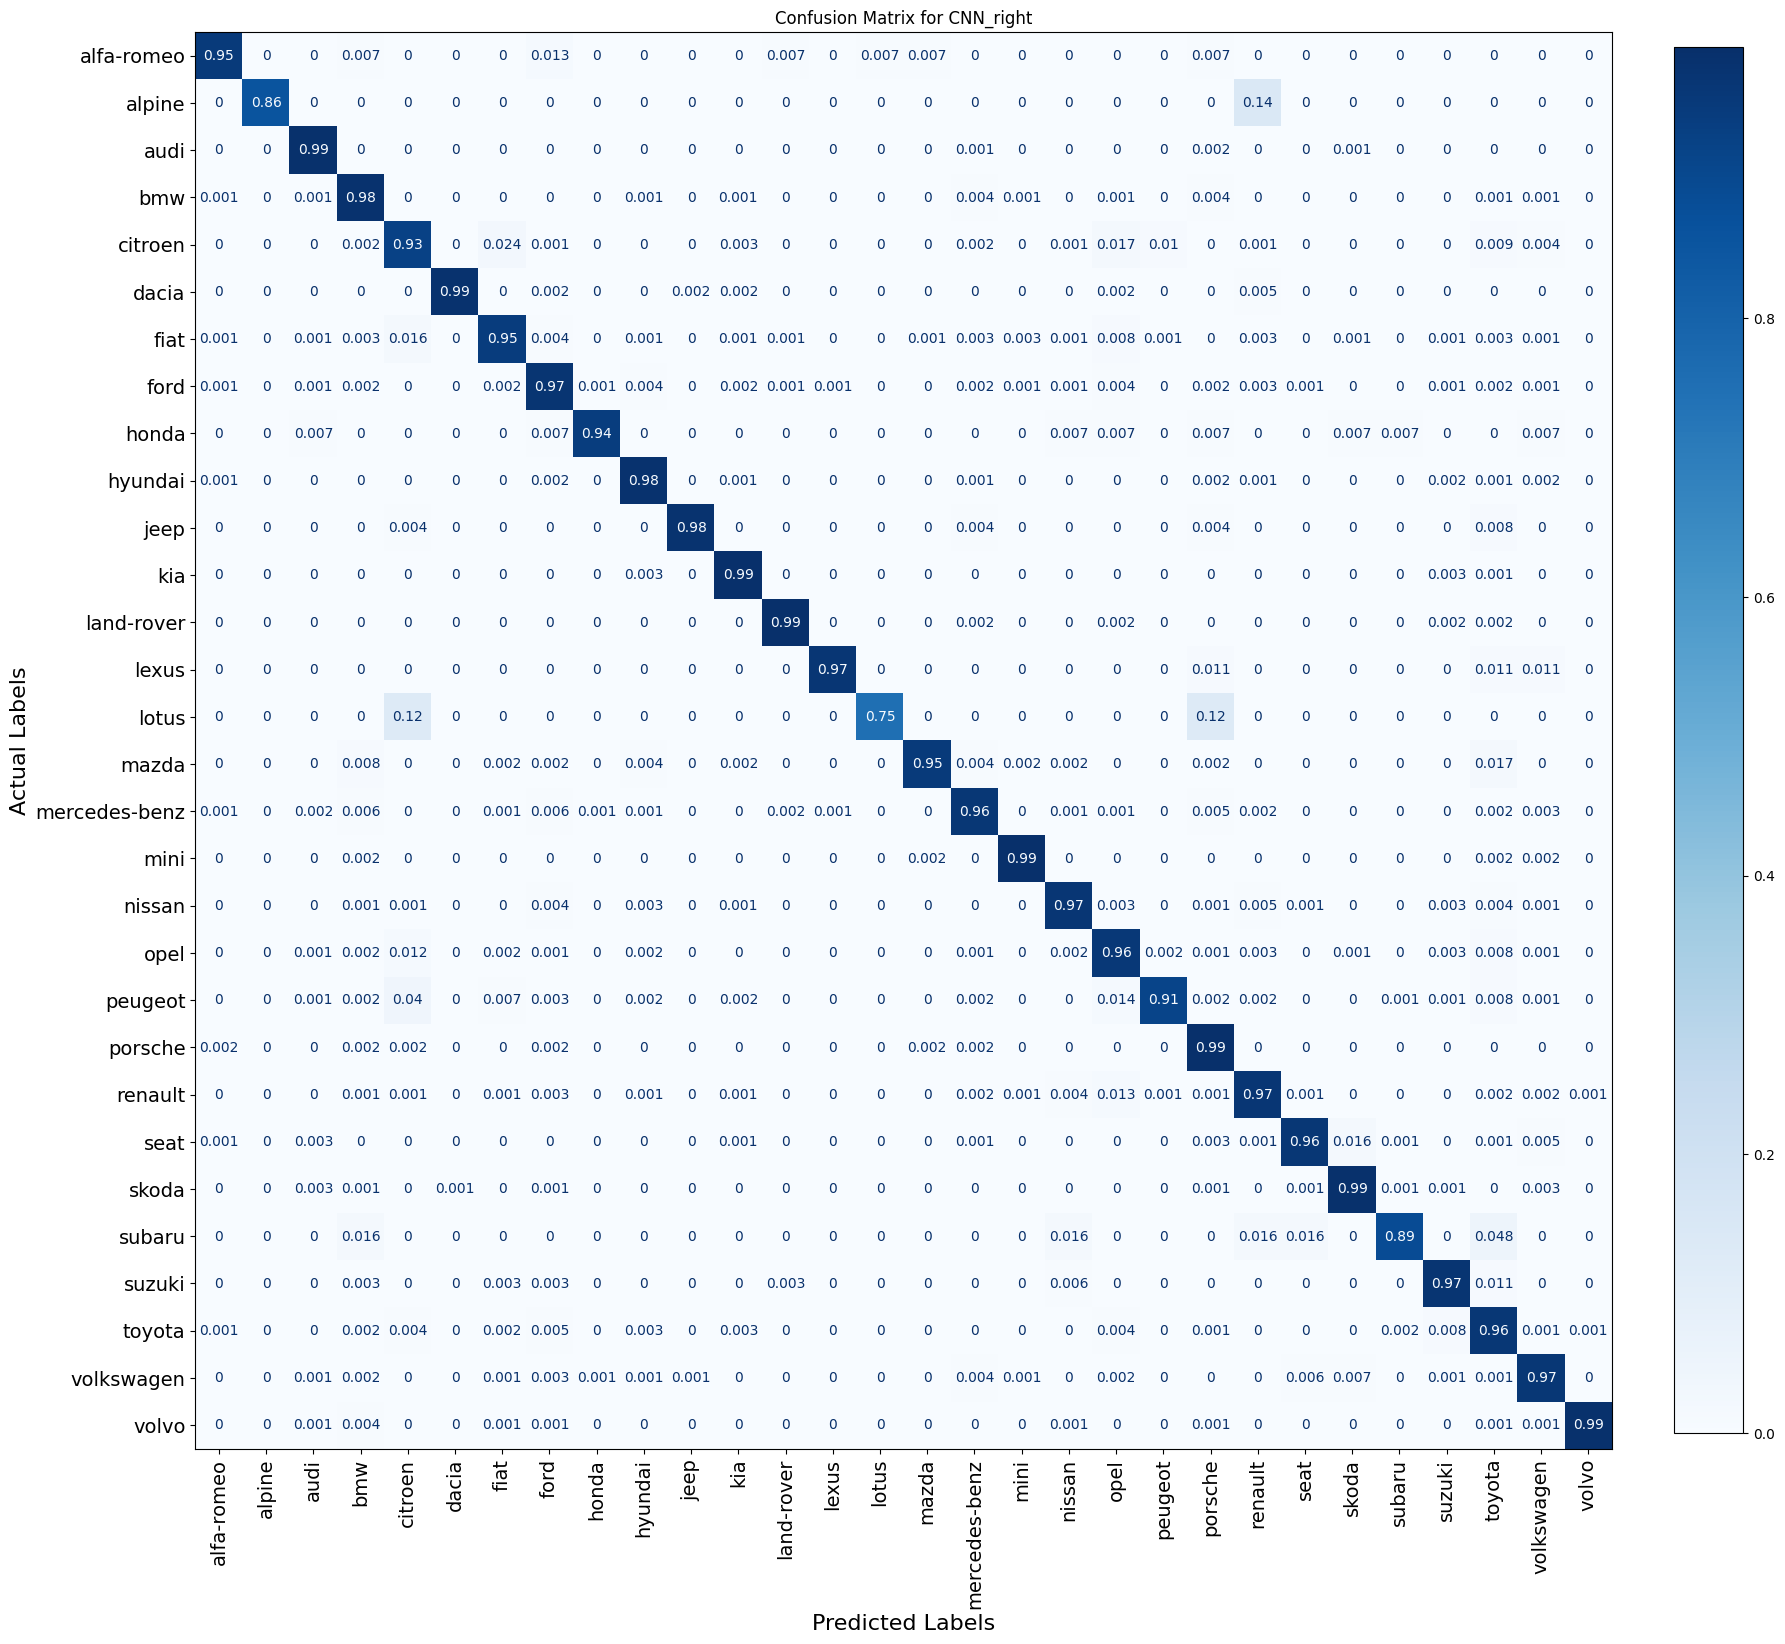

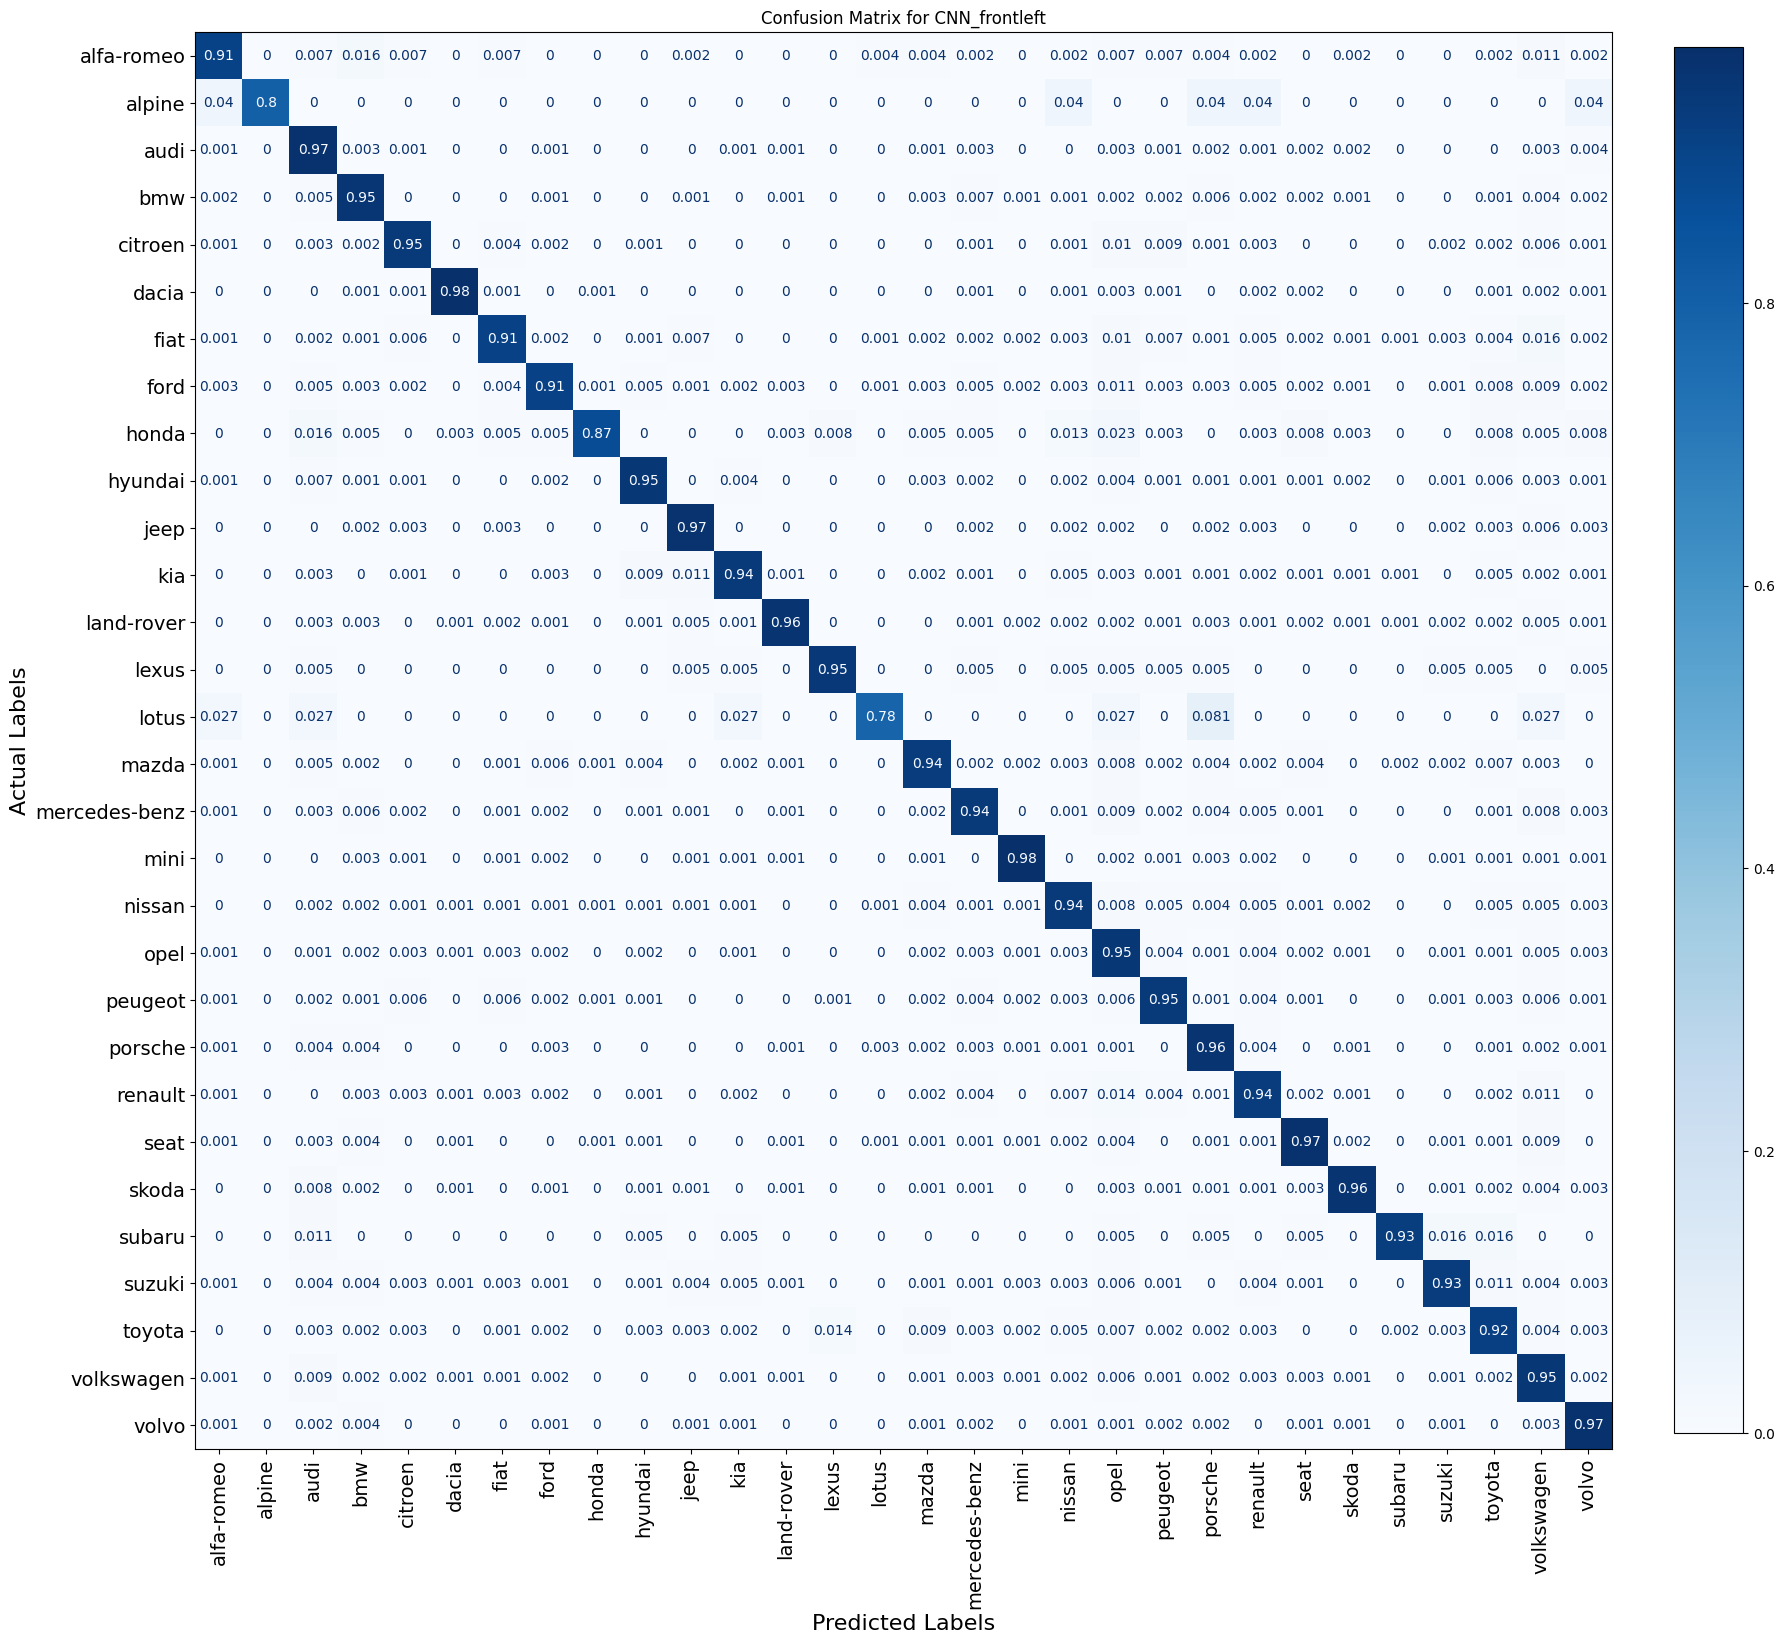

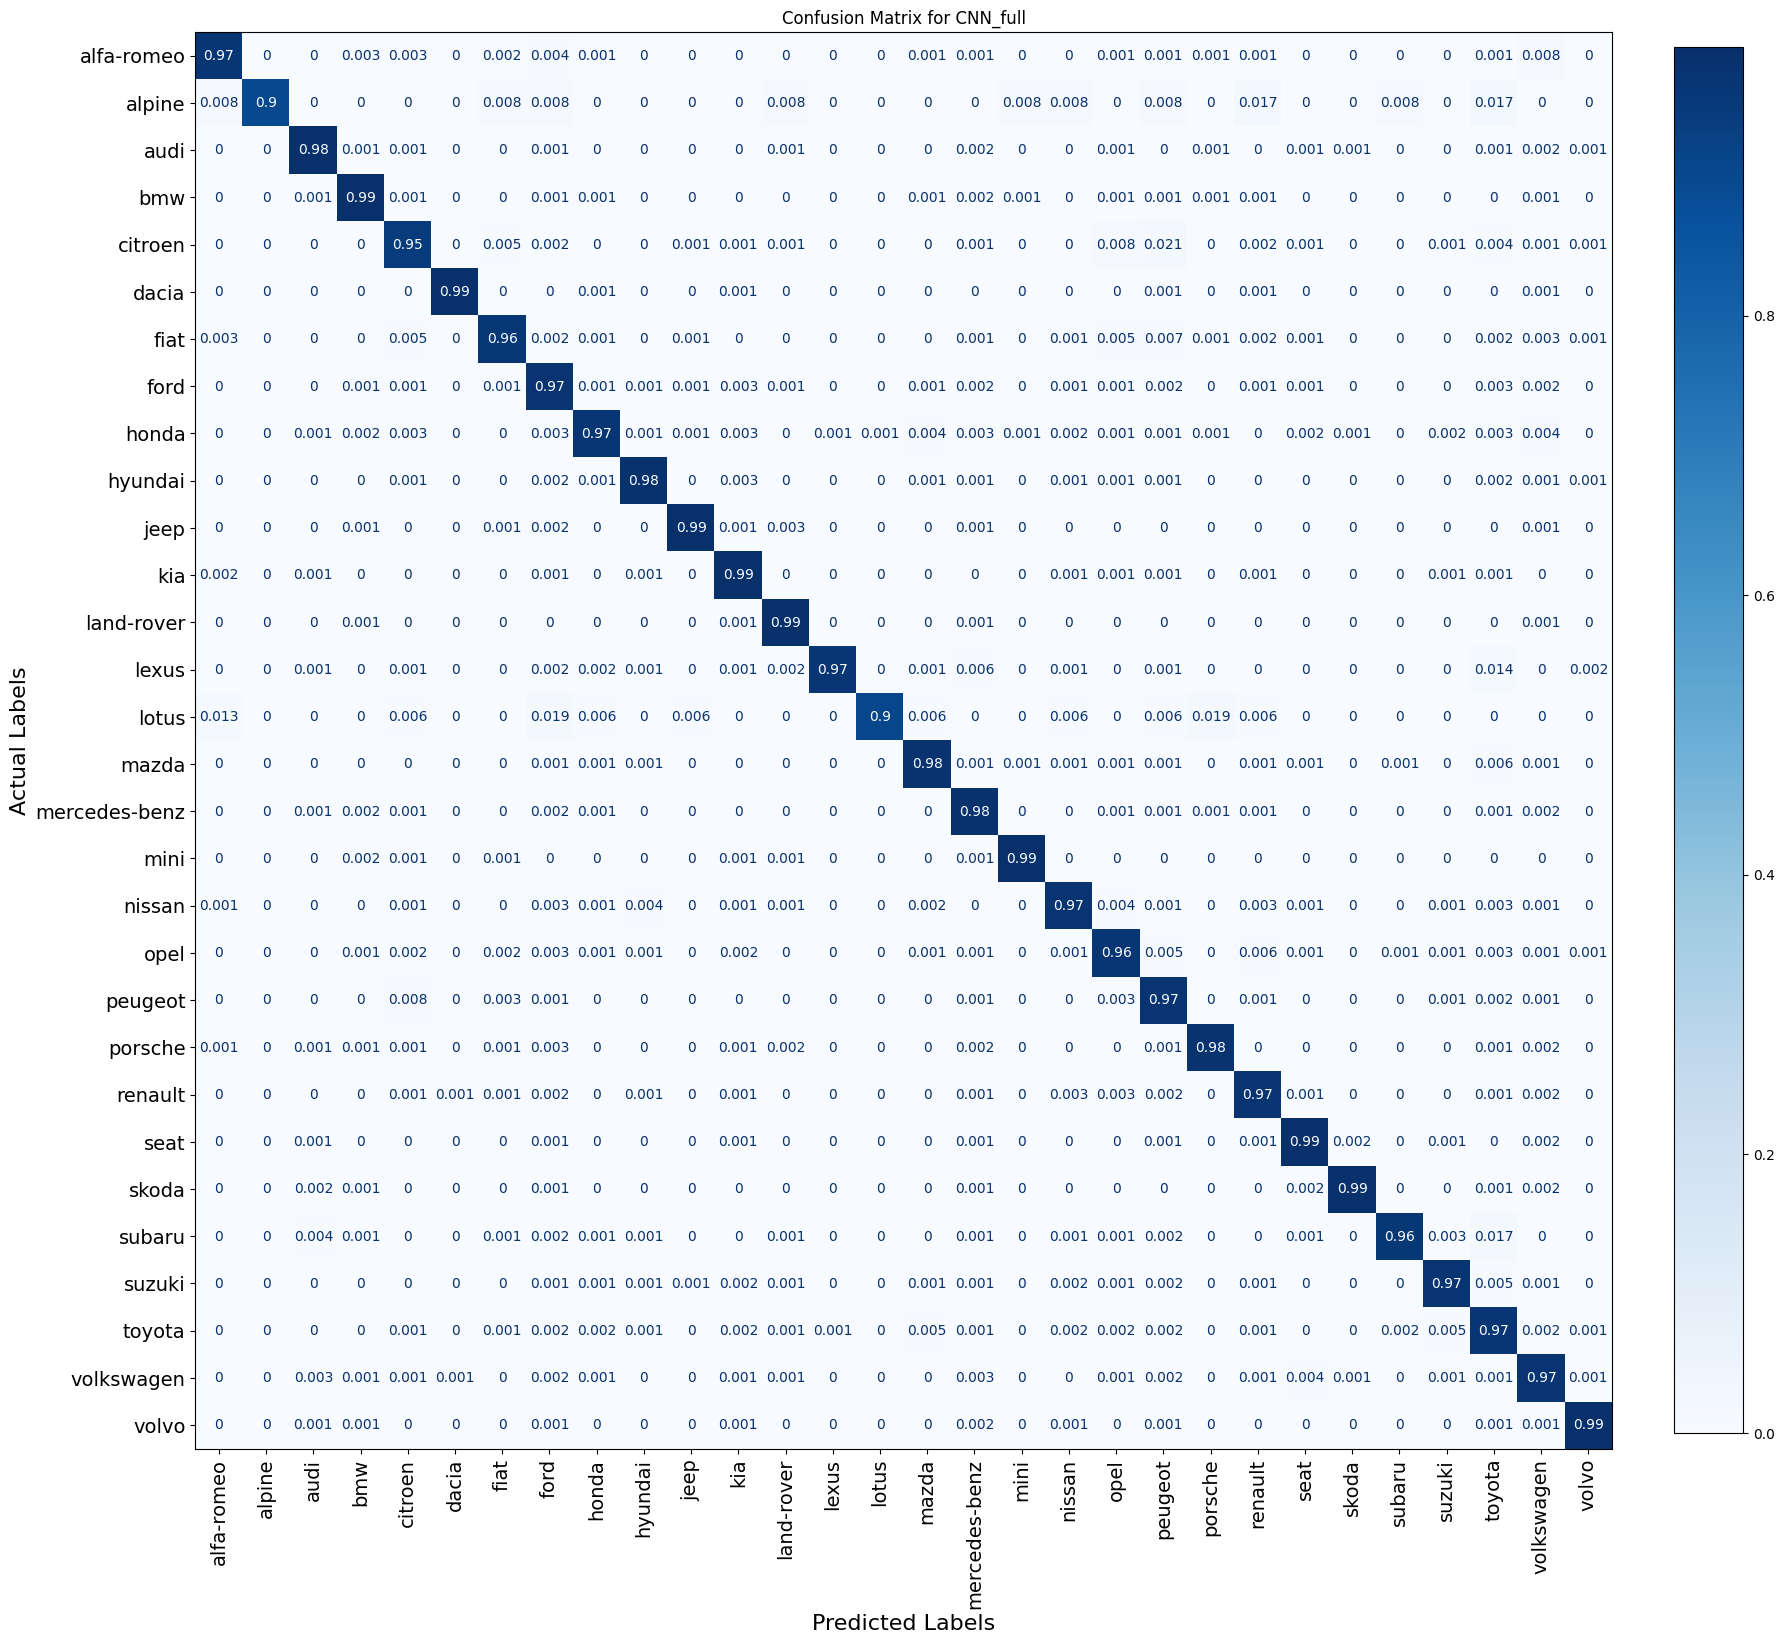

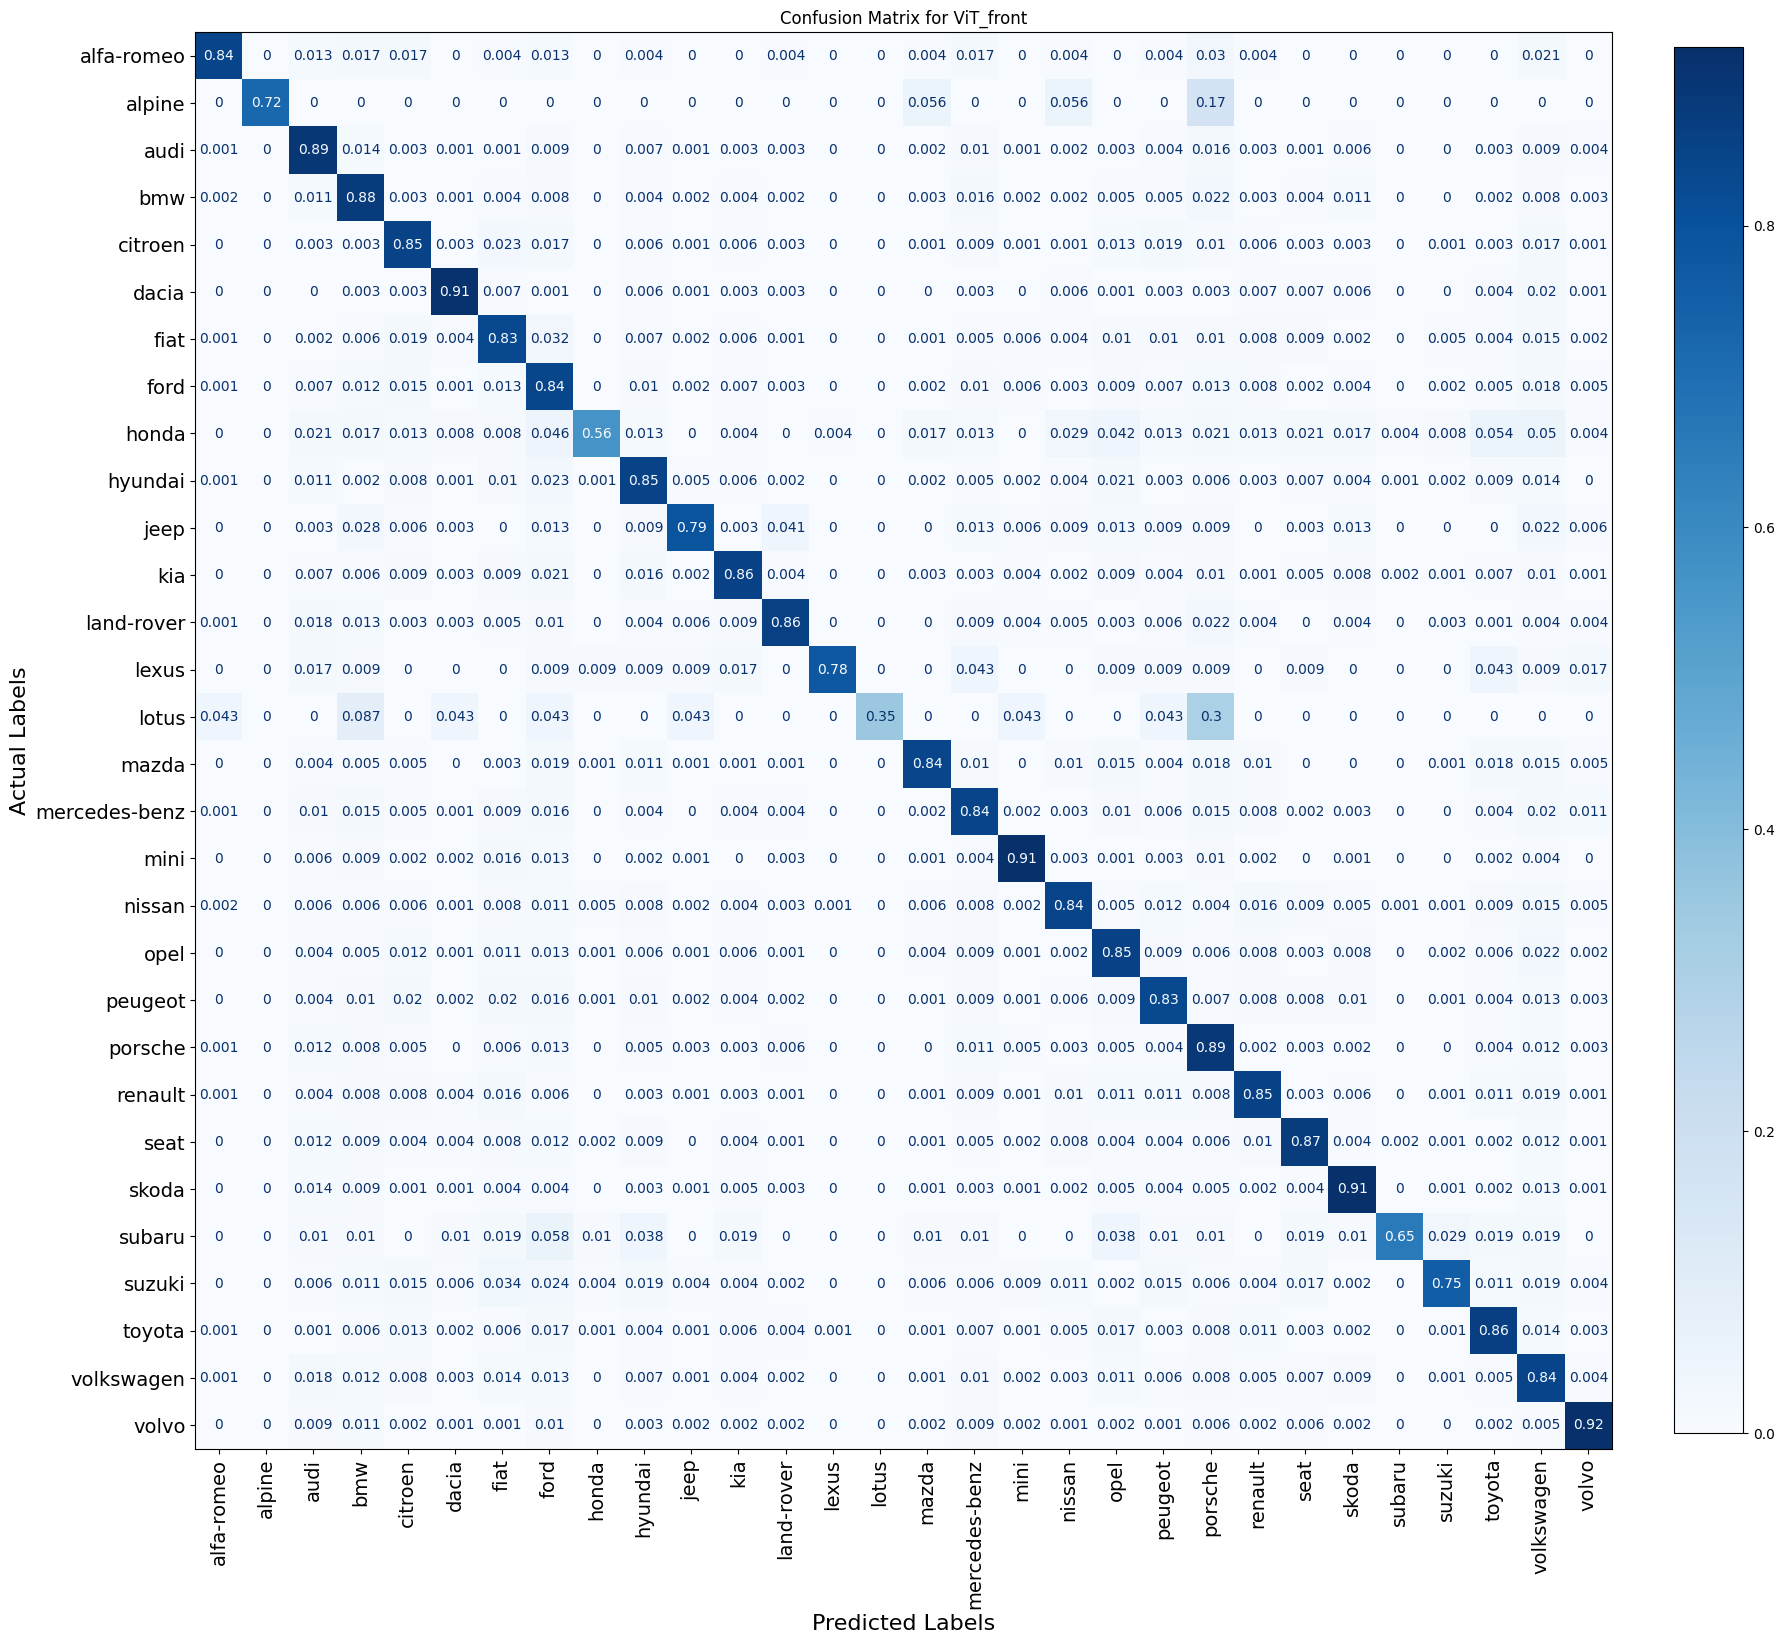

In [88]:
pooled_actuals = []
pooled_predicts = []
angle_metrics = {}
for profile, data in results.items():
    profile_name_short = profile.split('_')[0]
    for angle, valresults in data.items(): 
        encoded_prediction_labels = valresults['predicts']
        act = valresults['actuals']
        decoder =valresults['decoder']
        decoded_labels = decode_labels(decoder, encoded_prediction_labels)
        brand_names = decoder.values()
        pred = decoded_labels
        #POOL results to make an easy comparison of individual 
        #   training on angles vs one big model trained on all angles.
        if angle in validation_df.model_label.values and profile.lower().startswith('cnn'):
            pooled_actuals.extend(act)
            pooled_predicts.extend(pred)
        #multiangle only for CNN! We've alreay established that ViT isn't great
        if profile.lower().startswith('cnn'):
            angle_metrics[angle] = implot.quick_metrics(act, pred)
        cm = implot.make_cm(act, pred, brand_names)
        cm.title(f"Confusion Matrix for {profile_name_short+'_'+angle}")
        cm.show()

So we got a lot of CMs now, let's maybe focus on a few first: 



We've trained one big model on 2.4 million images (10.000 images per brand, per angle >> 10000x8x30) This was the traindataset; that same traindataset, could be broken down into 8 datasets of 10000 images per brand; these 8 datasets are the angled models and are trained to predict from a single only. 

Let's compare if pooling the results of 8 smaller models is betters than throwing all the data in a single model. 

In [90]:
data = results['CNN_based_models']
fa, fp = data['full']['actuals'], decode_labels(data['full']['decoder'], data['full']['predicts'])

full_cm, full_metrics = ez_compare(fa, fp, brand_names)
pooling_cm, pooling_metrics = ez_compare(pooled_actuals, pooled_predicts, brand_names)
metrics_pooling_or_full = {
    'pooled': pooling_metrics, 
    'full': full_metrics
    }

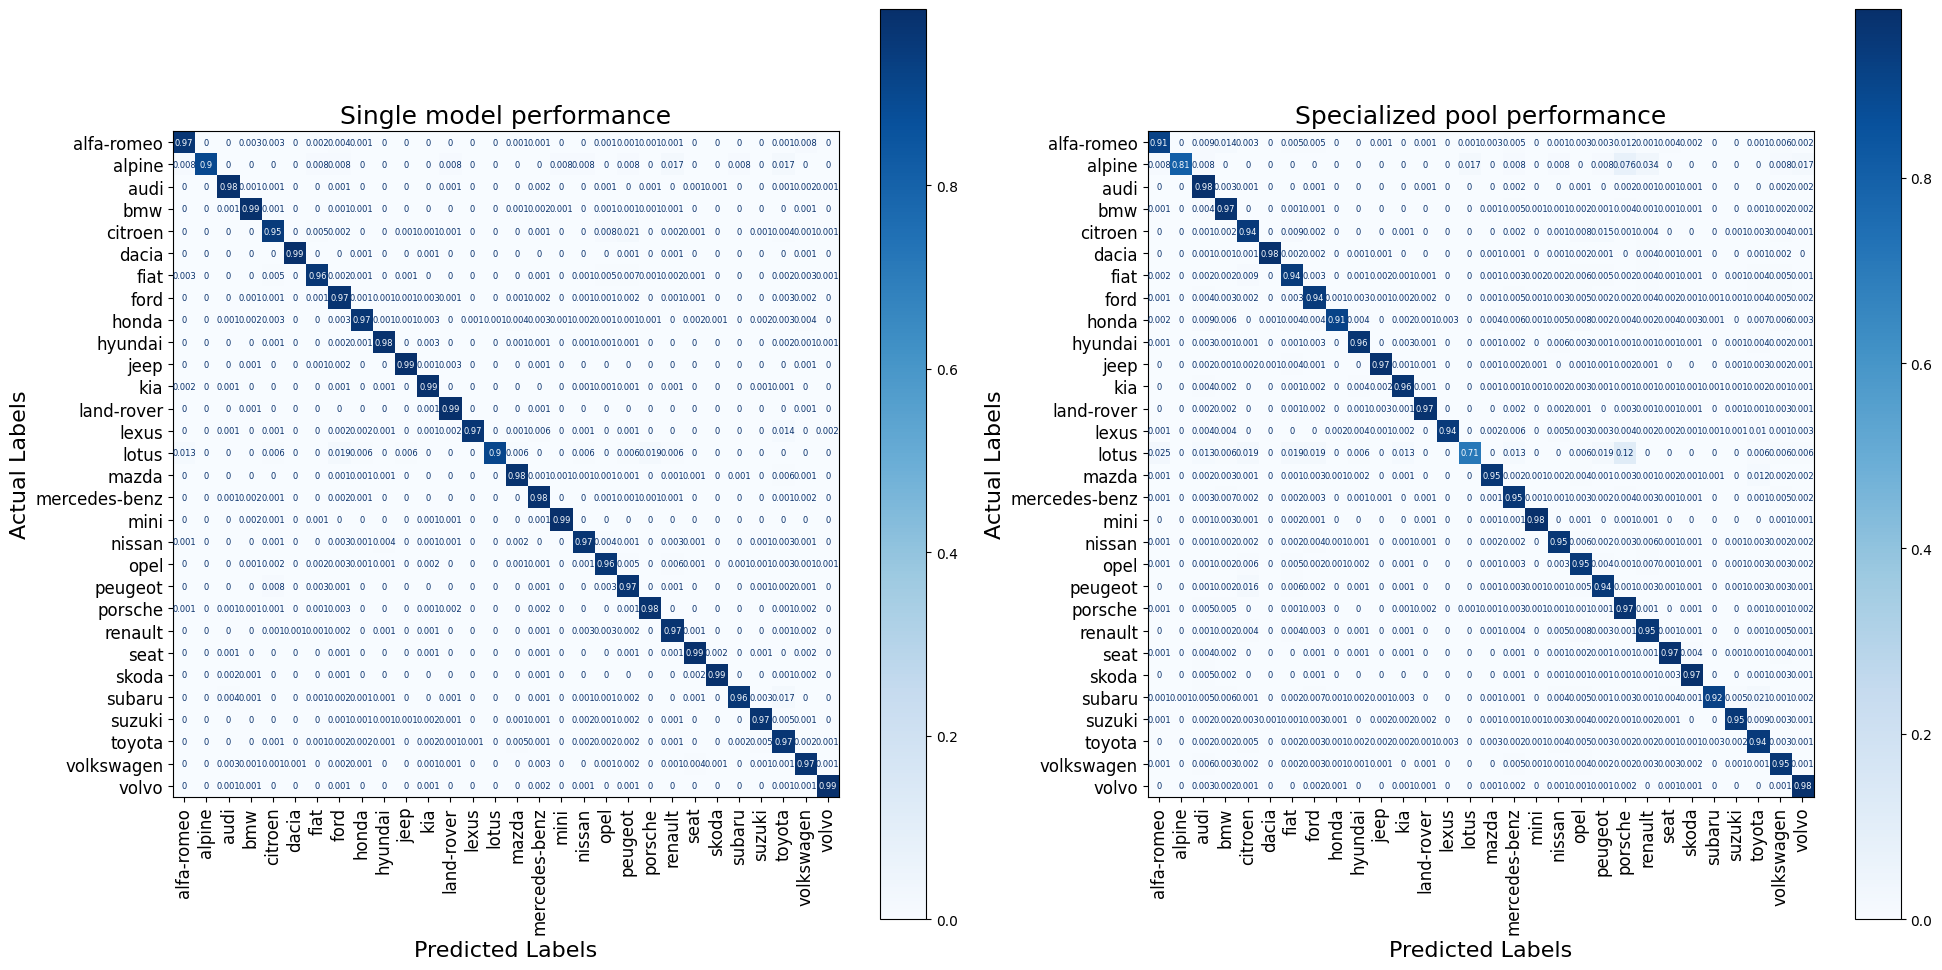

In [91]:
implot.side_by_side_cm(full_cm, 'Single model performance', pooling_cm, 'Specialized pool performance')

Interesting observation: Look at the performance for low-frequency brands; less-occuring brands seem to to gain a lot by using the full model over a specialized angle model.

- Alpine
- Alfa Romeo
- Honda
- Lotus
- Subaru
- Lexus 

these are all brands on the right side of the frequency distribution chart; the are all performing better when inferring from a single model than pooling the results from 8 specialized models. 

In [92]:
#Let's visualize that observation with a more clear plot. 
textObjects = {
    'title': 'Difference of full model vs pooling 8 models',
    'xaxis_title': 'Accuracy difference in percentpoints',
    'yaxis_title': 'Brands'
}
implot.compare_model_accuracies(fp, fa, pooled_predicts, pooled_actuals, list(brand_names), textObjects)

We can even make a starker observation: There's no accuracy penalty for ANY brand in using the full model. This is good news for two reasons: 
1) We can take a completely unknown image and directly infer the brand from it without needing to infer the angle first (Faster end-to-end). 
2) Improving error-rates in angle detector is now a very very very low - to non-existent priority. 

In [93]:
fig = implot.plot_quick_metrics(metrics_pooling_or_full)
fig.update_layout(
    height=800,
    width=1400,
    title_text='Inferring from 8 pooled models (one per angle) versus a single model trained on all angles',
    showlegend=False
)


I was not expecting this: a single model with the full dataset is performing better than a model that combines the results of 8 pooled specializations. Keep in mind though, that the full model was trained on BALANCED angles. So you should not interpret this as "training angle recognition was  not useful". To make that assesment a model should be trained on 80000 images per brand randomly sampled without balancing out the angle!

Across all metrics, the full model performs better than pooled performance. A possible explanation for this could be that errors in the angle-detection phase have a more pronounced effect if you only expect angle X; whereas a model that's open to all angles will see this as a (very slight) class imbalance. 

Performance wise, the full model is better than 8 models, each trained on a specific angle. HOWEVER, trainingswise there's a huge difference and we should be aware of this: 
- the angle-specific models CAN be trained in parallel on COLAB: copy the 3.3 notebook 8 times, configure each notebook to run training on a specific angle and you're done.
- The full model cannot be trained in parallel! 

The cost to train 8 specialized models was also lower (consuming ca. 330 Tokens on Google Colab with the L4 GPU High-Ram environment.). The full model was trained until the remaining 370 tokens where used up; at the time it reached the end of the available credits, the model was already in the final LR-phase but it hadn't met all criteria yet for Early stopping (so it could've improved a few promiles more). 

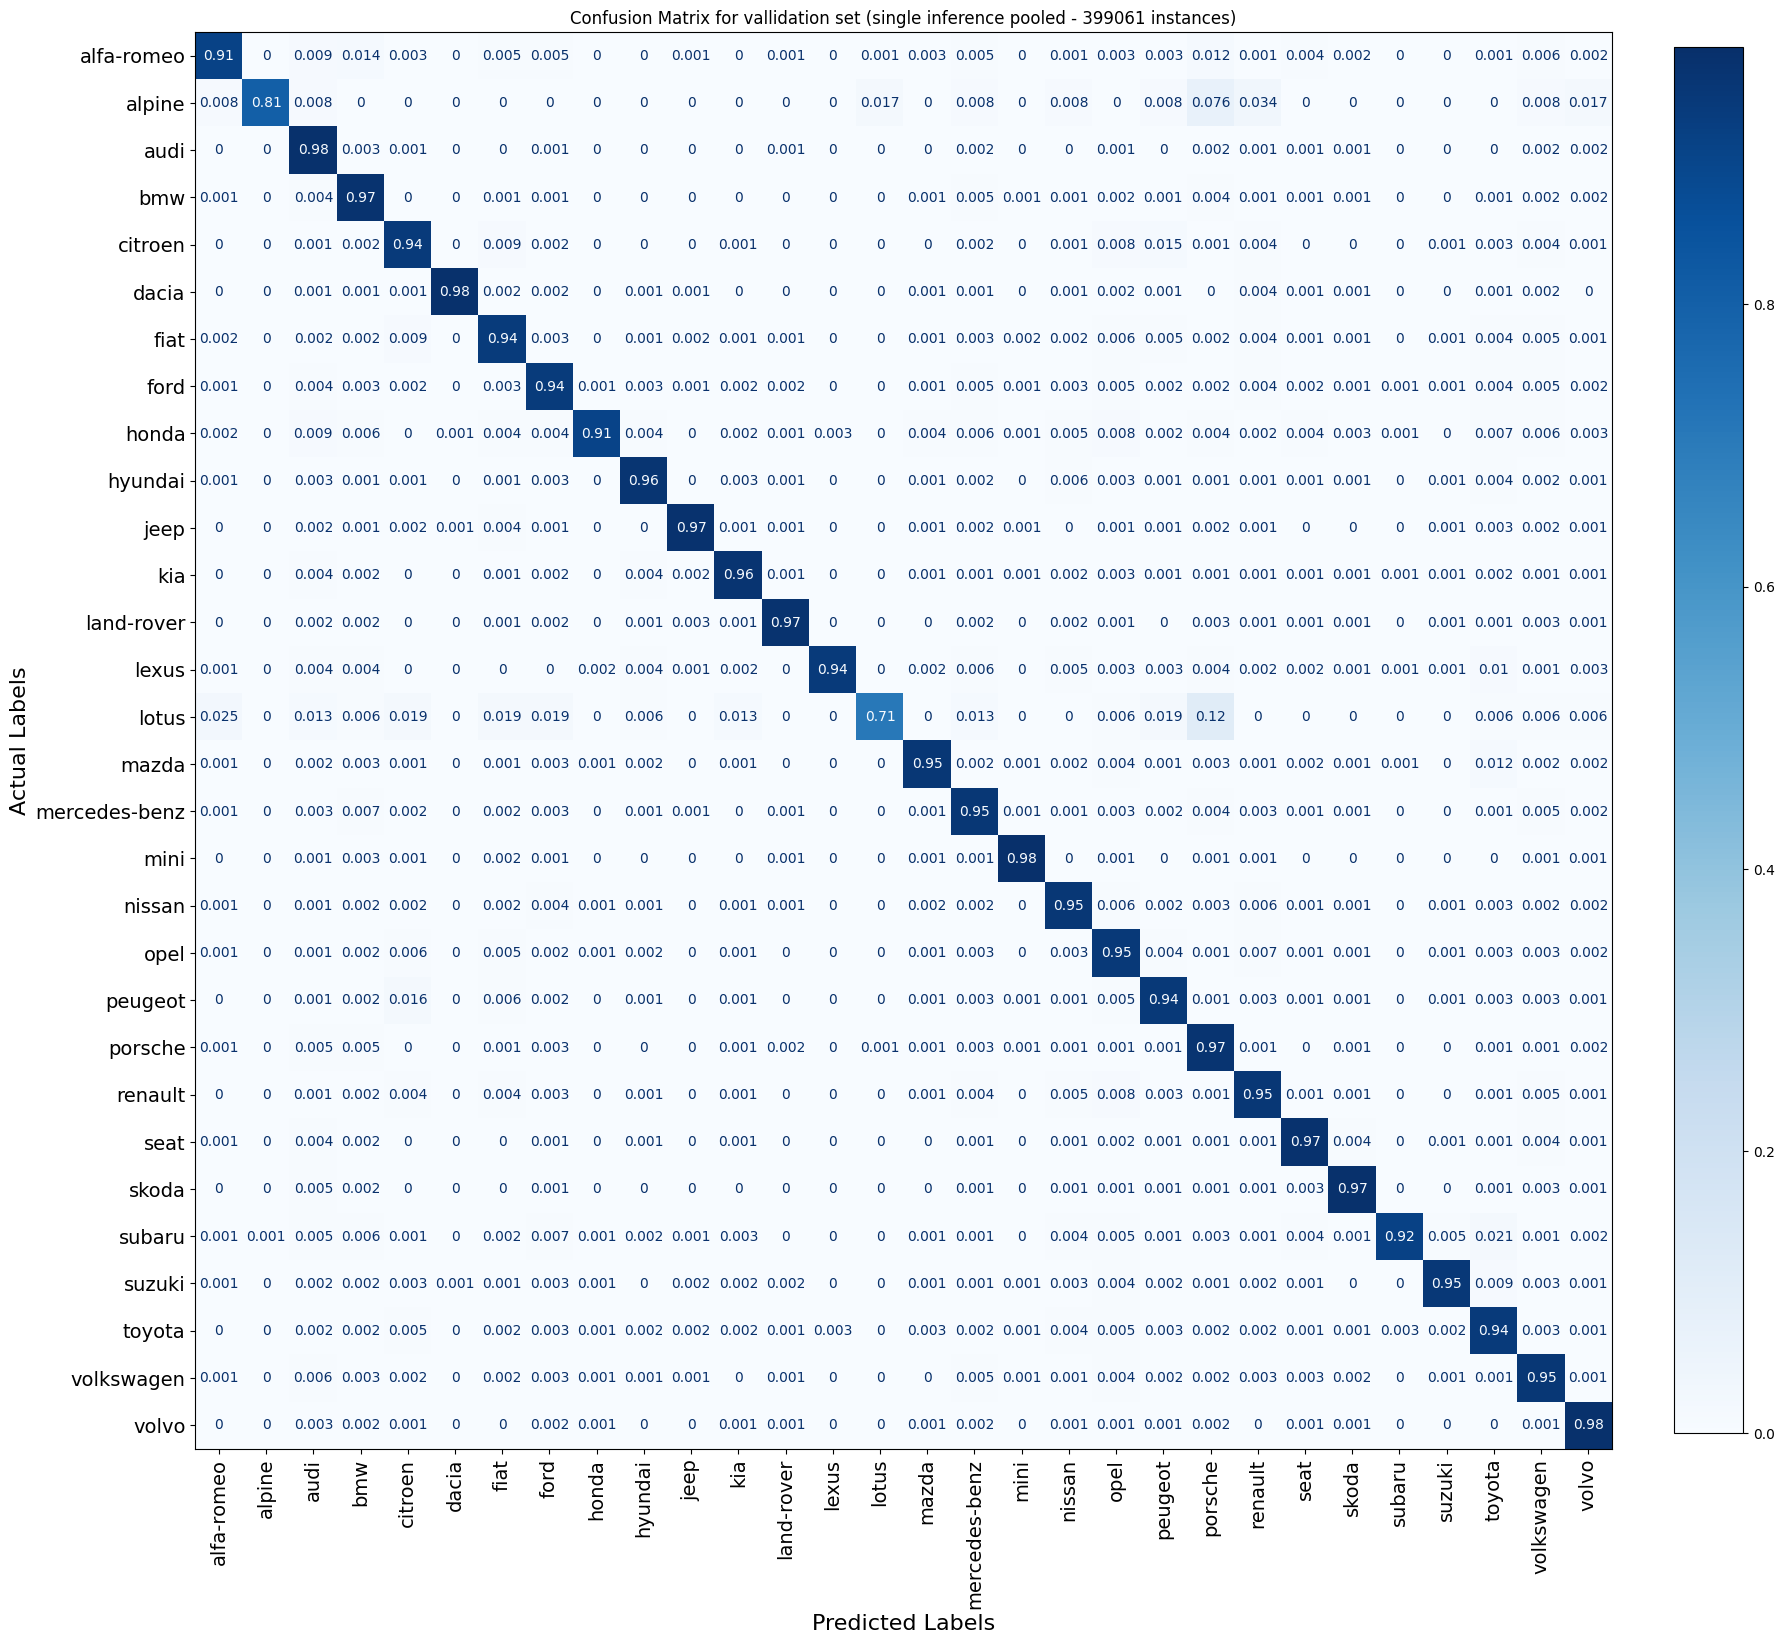

In [94]:
# Pooled single inference performance: 
cm = implot.make_cm(pooled_actuals, pooled_predicts, brand_names)
cm.title(f"Confusion Matrix for vallidation set (single inference pooled - {len(pooled_actuals)} instances)")
cm.show()


#TODO use the implot.quicplot method for quickmetrics outcome!
angle_metrics['pooled'] = implot.quick_metrics(pooled_actuals, pooled_predicts)


In [95]:
fig = implot.plot_quick_metrics(angle_metrics)#meh, let's make individual plots. 
fig.update_layout(
    height=900,
    width=1500,
    title_text='CNN only: 8 angles + Pooling + Single full',
    showlegend=False
)

In [96]:
print(angle_metrics['pooled']['Accuracy'])
print(angle_metrics['full']['Accuracy'])


0.9572245847126128
0.977868045236192


Using eight specialised models based on a CNN gave an **accuracy** across the full validation set of **95,72%**; using a single CNN-based model of EQUAL angle distributation gave us **97.778%** accuracy.

## 3.6.7 The FULL model is superior when looking at the performance metrics. 

Let's make a few more visualizations to assess this performance and wrap it up. 

In [ ]:
brandacc = implot.brand_accuracy_plot(fa, fp)
brandacc.update_layout(title="Per-brand accuracy (sorted)")



In [127]:
misses = implot.brand_missclassification_plot(fa, fp)
misses.update_layout(title="Misclassification frequency per brand (errors only)")
